**1[a]. Identify the months with the highest and lowest acquisition rates.**

In [ ]:
import pandas as pd

# Load the Online_Sales.csv file
online_sales_df = pd.read_csv('Online_Sales.csv')

# Convert 'Transaction_Date' to datetime objects
online_sales_df['Transaction_Date'] = pd.to_datetime(online_sales_df['Transaction_Date'])

# Find the first transaction date for each customer (acquisition date)
customer_acquisition_dates = online_sales_df.groupby('CustomerID')['Transaction_Date'].min().reset_index()
customer_acquisition_dates.rename(columns={'Transaction_Date': 'Acquisition_Date'}, inplace=True)

# Extract the month from the acquisition date
customer_acquisition_dates['Acquisition_Month'] = customer_acquisition_dates['Acquisition_Date'].dt.to_period('M')

# Count the number of new customers acquired per month
monthly_acquisitions = customer_acquisition_dates['Acquisition_Month'].value_counts().sort_index().reset_index()
monthly_acquisitions.columns = ['Month', 'New_Customers']

# Convert the 'Month' column back to datetime and then to month names
monthly_acquisitions['Month'] = monthly_acquisitions['Month'].dt.strftime('%B')


# Identify the month with the highest acquisition rate
highest_acquisition_month_data = monthly_acquisitions.iloc[0]
highest_acquisition_month = highest_acquisition_month_data['Month']
highest_acquisition_count = highest_acquisition_month_data['New_Customers']

# Identify the month with the lowest acquisition rate
lowest_acquisition_month_data = monthly_acquisitions.iloc[-1]
lowest_acquisition_month = lowest_acquisition_month_data['Month']
lowest_acquisition_count = lowest_acquisition_month_data['New_Customers']

print("Monthly Acquisitions with Month Names:\n", monthly_acquisitions)
print(f"\nMonth with Highest Acquisition Rate: {highest_acquisition_month} with {highest_acquisition_count} new customers.")
print(f"Month with Lowest Acquisition Rate: {lowest_acquisition_month} with {lowest_acquisition_count} new customers.")

Monthly Acquisitions with Month Names:
         Month  New_Customers
0     January            215
1    February             96
2       March            177
3       April            163
4         May            112
5        June            137
6        July             94
7      August            135
8   September             78
9     October             87
10   November             68
11   December            106

Month with Highest Acquisition Rate: January with 215 new customers.
Month with Lowest Acquisition Rate: December with 106 new customers.


**1[b].What strategies could be implemented to address the fluctuations and ensure consistent growth throughout the year**

1. **Customer Lifetime Value (CLTV) Analysis:** Investigate if customers acquired in peak months (like January 2019) versus trough months (like November 2019) have different CLTVs. This helps in understanding the true value of customers acquired during different periods and informs where to invest marketing efforts.
    * **Channel Performance by Month:** Analyze your marketing spend and channel effectiveness from `Marketing_Spend.csv` to identify which online and offline channels yield the best results during different months. This allows for dynamic budget reallocation.
    * **Product Performance by Month:** Examine your `Online_Sales.csv` data to see if specific product categories exhibit seasonal demand patterns. This can guide inventory management and targeted promotions.

2.  **Strategic Marketing and Sales Adjustments:**
    * **Capitalize on Peak Periods (e.g., January):**
        * **Post-Holiday Engagement:** Leverage the natural surge in consumer activity in January (often driven by New Year's resolutions or post-holiday spending). Run targeted campaigns focused on new beginnings, self-improvement, or special offers on relevant products.
        * **Early Retention Focus:** Given the high volume of new customers, prioritize robust onboarding and early retention programs to maximize the long-term value of these acquisitions.
    * **Boost Trough Periods (e.g., November):**
        * **Pre-Holiday Warm-up Campaigns:** November is a critical month leading into major holiday shopping. Instead of a slump, treat it as an opportunity for early holiday sales, exclusive sneak peeks, or pre-Black Friday/Cyber Monday promotions.
        * **Targeted Offers and Bundles:** Utilize data from `Discount_Coupon.csv` to create highly attractive, category-specific discounts or product bundles that incentivize purchases during slower months.
        * **Customer Referrals & Loyalty Programs:** During quieter periods, focus on leveraging existing customer base. Encourage referrals with compelling incentives, and strengthen loyalty programs to drive repeat purchases and consistent revenue.
        * **Re-engagement Campaigns:** Actively re-engage past website visitors or inactive customers through email marketing, retargeting ads, and personalized offers to bring them back.
    * **Diversify Acquisition Channels:** Reduce over-reliance on a single channel. A mix of organic (SEO, content marketing, social media), paid (PPC, social media ads), referral programs, and strategic partnerships can create a more stable influx of customers.
    * **Content Calendar Alignment:** Develop a content strategy that aligns with seasonal interests and pain points throughout the year, keeping your brand visible and relevant.

3.  **Enhance Customer Retention and Lifetime Value (LTV):**
    * **Robust Onboarding and Customer Success:** Ensure a seamless onboarding process for all new customers. Proactive customer success initiatives help ensure customers are deriving value from product/service, leading to higher satisfaction and retention.
    * **Personalized Communication:** Utilize customer demographic data from `Customers_Data.csv` (e.g., `Gender`, `Location`, `Tenure_Months`) to send personalized communications, product recommendations, and offers.
    * **Feedback Loops:** Regularly collect and analyze customer feedback to continuously improve products and services, which directly contributes to higher retention rates.

4.  **Operational and Product Adjustments:**
    * **Seasonal Product/Service Offerings:** Consider introducing products or services that cater to specific seasonal demands or trends during traditionally slower months to stimulate interest and generate additional revenue.
    * **Dynamic Pricing:** Implement flexible pricing strategies, such as offering discounts or special bundles during off-peak seasons to encourage purchases, and optimizing pricing during peak demand.
    * **Consistent Customer Service Excellence:** Maintain a high standard of customer service year-round. Excellent service fosters loyalty, reduces churn, and encourages positive word-of-mouth referrals, contributing to organic growth in all seasons.

**2[a]. Analyze the data to determine if certain months consistently show higher or lower acquisition rates.**

In [ ]:
monthly_acquisitions_sorted = monthly_acquisitions.sort_values(by='New_Customers', ascending=False)
#higher acquisition rates.
monthly_acquisitions_sorted.head(3)

,Month,New_Customers
0,January,215
2,March,177
3,April,163


In [ ]:
#lower acquisition rates.
monthly_acquisitions_sorted.tail(3)

,Month,New_Customers
9,October,87
8,September,78
10,November,68


**2[b].How can the company capitalize on high-performing months and improve performance during slower periods?**

Based on the analysis of your customer acquisition data, here are the key findings regarding monthly acquisition rates and strategies for optimizing performance:

**Monthly Customer Acquisition Rates:**

* **High-Performing Months:** January consistently shows the highest acquisition rate with 215 new customers, followed by March (177) and April (163).
* **Lower-Performing Months:** November (68), September (78), July (94), and February (96) are periods with noticeably lower acquisition rates. Other months like December (106), May (112), August (135), June (137), and October (87) also fall into this category when compared to the peak months.

**Capitalizing on High-Performing Months (January, March, April):**

To maximize customer acquisition during these peak periods, the company can:

1.  **Intensify Marketing Campaigns:** Allocate a larger portion of the marketing budget to paid advertising (PPC, social media ads) and content marketing during these months to capture the heightened customer interest and traffic.
2.  **Launch Targeted Promotions:** Introduce exclusive, time-sensitive offers, discounts, or bundled packages that align with the seasonal themes of these months (e.g., New Year deals in January, early spring promotions).
3.  **Boost Referral Programs:** Actively promote and incentivize referral programs, as word-of-mouth marketing is highly effective when customer interest is naturally high.
4.  **Strategic Product Launches/Updates:** Consider launching new products or significant updates during these months to leverage existing momentum and generate buzz.
5.  **Optimize Conversion Funnels:** Ensure that the website, landing pages, and checkout processes are highly efficient and user-friendly to convert the increased traffic into customers seamlessly.

**Improving Performance During Slower Periods (November, September, July, February, December, May, August, June, October):**

During months with lower acquisition rates, the company can implement targeted interventions:

1.  **Re-engage Past Customers:** Focus on personalized email campaigns and special offers to re-engage existing or dormant customers, as retaining customers is often more cost-effective than acquiring new ones.
2.  **Invest in Long-Term Content and SEO:** Use these periods to build organic traffic and authority by creating high-quality, valuable content (blogs, guides, videos) and optimizing for search engines. This can yield sustained results over time.
3.  **Strengthen Loyalty and Referral Programs:** Double down on customer loyalty initiatives and referral programs, making them even more appealing to encourage existing customers to bring in new leads.
4.  **Explore Strategic Partnerships:** Form collaborations with complementary businesses to cross-promote and access new customer segments.
5.  **Implement Data-Driven Personalization:** Utilize customer data to create highly personalized marketing messages and offers, nurturing leads over a longer sales cycle.
6.  **Review and Refine Sales Strategies:** Analyze past sales data from slow periods to identify specific trends, adjust pricing strategies, explore bundling opportunities, or diversify sales channels.
7.  **Gather Customer Feedback and Innovate:** Use the slower pace to gather in-depth customer feedback, address pain points, and develop new features or products that resonate with customer needs, increasing overall product appeal and reducing churn.
8.  **Internal Training and Development:** Invest in training for sales and marketing teams to enhance their skills, optimize processes, and better understand customer behavior during challenging periods.

By understanding these monthly trends and implementing a tailored strategy for both high-performing and slower periods, the company can effectively capitalize on its strengths and address areas for improvement in customer acquisition.

**3[a]. Identify periods with the strongest and weakest retention rates.**

In [ ]:
import pandas as pd

# Load the datasets
online_sales_df = pd.read_csv('Online_Sales.csv')
customers_df = pd.read_excel('CustomersData.xlsx')

# Convert 'Transaction_Date' to datetime objects
online_sales_df['Transaction_Date'] = pd.to_datetime(online_sales_df['Transaction_Date'], format='%m/%d/%Y')

# Extract 'Transaction_Month' (year and month)
online_sales_df['Transaction_Month'] = online_sales_df['Transaction_Date'].dt.to_period('M')

# Get the first transaction month for each customer (cohort month)
customer_first_purchase = online_sales_df.groupby('CustomerID')['Transaction_Month'].min().reset_index()
customer_first_purchase.columns = ['CustomerID', 'Cohort_Month']

# Merge cohort month with sales data
df_merged = pd.merge(online_sales_df, customer_first_purchase, on='CustomerID')

# Calculate the difference in months between transaction month and cohort month
df_merged['Month_Number'] = (df_merged['Transaction_Month'] - df_merged['Cohort_Month']).apply(lambda x: x.n)

# Count unique customers for each cohort and month number
cohort_counts = df_merged.groupby(['Cohort_Month', 'Month_Number'])['CustomerID'].nunique().reset_index()

# Create a pivot table for retention
retention_pivot = cohort_counts.pivot_table(index='Cohort_Month', columns='Month_Number', values='CustomerID')

# Calculate the cohort size (number of unique customers in the first month)
cohort_sizes = retention_pivot.iloc[:, 0]

# Divide all values by the cohort size to get retention rates
retention_rates = retention_pivot.divide(cohort_sizes, axis=0) * 100

# Calculate average retention for each month number (excluding month 0 as it's always 100%)
average_retention_per_month = retention_rates.iloc[:, 1:].mean().reset_index()
average_retention_per_month.columns = ['Month_Number', 'Average_Retention_Rate']

# Convert 'Month_Number' to integer for better readability and to ensure that the months are 1-indexed.
average_retention_per_month['Month_Number'] = average_retention_per_month['Month_Number'].astype(int) + 1

# Identify periods with the strongest and weakest retention rates
strongest_retention_month = average_retention_per_month.loc[average_retention_per_month['Average_Retention_Rate'].idxmax()]
weakest_retention_month = average_retention_per_month.loc[average_retention_per_month['Average_Retention_Rate'].idxmin()]

print("\nRetention Rates (Cohort Analysis):")
print(retention_rates)

print("\nAverage Retention Rate per Month (excluding month 0):")
print(average_retention_per_month)

print(f"\nMonth with Strongest Retention: Month {strongest_retention_month['Month_Number']} with {strongest_retention_month['Average_Retention_Rate']:.2f}% retention")
print(f"Month with Weakest Retention: Month {weakest_retention_month['Month_Number']} with {weakest_retention_month['Average_Retention_Rate']:.2f}% retention")


Retention Rates (Cohort Analysis):
Month_Number     0          1          2          3          4          5   \
Cohort_Month                                                                 
2019-01       100.0   6.046512  11.162791  15.813953  10.697674  20.465116   
2019-02       100.0   7.291667   9.375000  16.666667  17.708333  22.916667   
2019-03       100.0  10.169492  19.774011  14.124294  18.079096  18.644068   
2019-04       100.0   8.588957  14.723926  14.723926  11.042945   9.202454   
2019-05       100.0  10.714286   8.035714  11.607143   8.928571  11.607143   
2019-06       100.0  14.598540  16.058394   8.759124   8.029197  10.218978   
2019-07       100.0  13.829787   4.255319   6.382979  11.702128   9.574468   
2019-08       100.0  10.370370  11.111111   7.407407   5.925926        NaN   
2019-09       100.0   7.692308   3.846154   2.564103        NaN        NaN   
2019-10       100.0   6.896552   4.597701        NaN        NaN        NaN   
2019-11       100.0  10.2941

**3[b]. What strategies could be implemented to improve retention during weaker months?**

To improve retention during weaker months, particularly in Month 2, the following strategies could be implemented:

1.  **Personalized Engagement Campaigns**:
    * **Automated follow-ups**: Implement automated email or in-app messages to check in with customers who haven't made a purchase in Month 2 since their initial transaction.
    * **Tailored recommendations**: Based on past purchase history, offer personalized product recommendations or content that aligns with their interests.

2.  **Incentives and Exclusive Offers**:
    * **Limited-time discounts**: Introduce exclusive discounts or promotions specifically for customers in their second month to encourage repeat purchases.
    * **Loyalty program benefits**: Highlight loyalty program benefits or offer bonus points for purchases made during the weaker retention period.

3.  **Customer Feedback and Support**:
    * **Proactive outreach**: Reach out to customers who are in their second month to gather feedback on their experience and address any potential issues.
    * **Enhanced customer support**: Ensure that customer support channels are easily accessible and provide prompt, helpful responses to any queries or concerns.

4.  **Content and Community Building**:
    * **Engaging content**: Share valuable content such as tutorials, tips, or product guides to keep customers engaged with the brand.
    * **Community initiatives**: Foster a sense of community by inviting customers to join forums, social media groups, or online events where they can interact with other users and the brand.

5.  **Re-engagement Campaigns**:
    * **Win-back offers**: For customers who show signs of churning after their first month, offer compelling win-back incentives to entice them to return.
    * **Survey and feedback requests**: Ask customers who haven't made a repeat purchase for their feedback on why they might not be returning, to identify and address underlying issues.

By implementing a combination of these strategies, the aim is to proactively engage with customers during weaker retention periods, address potential pain points, and provide compelling reasons for them to continue their relationship with the brand.

**4. Analyze customer behavior during high-retention months and suggest ways to replicate this success throughout the year.**

In [ ]:
import pandas as pd

# Load the datasets again if not already loaded in the current session
online_sales_df = pd.read_csv('Online_Sales.csv')
discount_coupon_df = pd.read_csv('Discount_Coupon.csv')
marketing_spend_df = pd.read_csv('Marketing_Spend.csv')

# Convert 'Transaction_Date' to datetime objects
online_sales_df['Transaction_Date'] = pd.to_datetime(online_sales_df['Transaction_Date'], format='%m/%d/%Y')

# Extract 'Transaction_Month' (year and month)
online_sales_df['Transaction_Month'] = online_sales_df['Transaction_Date'].dt.to_period('M')

# Get the first transaction month for each customer (cohort month)
customer_first_purchase = online_sales_df.groupby('CustomerID')['Transaction_Month'].min().reset_index()
customer_first_purchase.columns = ['CustomerID', 'Cohort_Month']

# Merge cohort month with sales data
df_merged = pd.merge(online_sales_df, customer_first_purchase, on='CustomerID')

# Calculate the difference in months between transaction month and cohort month
df_merged['Month_Number'] = (df_merged['Transaction_Month'] - df_merged['Cohort_Month']).apply(lambda x: x.n)

# Filter data for high-retention month (Month 12 corresponds to Month_Number = 11)
high_retention_data = df_merged[df_merged['Month_Number'] == 11]

# Filter data for low-retention month (Month 2 corresponds to Month_Number = 1)
low_retention_data = df_merged[df_merged['Month_Number'] == 1]

# Analyze Coupon_Status in high-retention month
coupon_status_high_retention = high_retention_data['Coupon_Status'].value_counts(normalize=True) * 100

# Analyze Coupon_Status in low-retention month
coupon_status_low_retention = low_retention_data['Coupon_Status'].value_counts(normalize=True) * 100

# Analyze Product_Category in high-retention month
product_category_high_retention = high_retention_data['Product_Category'].value_counts(normalize=True) * 100

# Analyze Product_Category in low-retention month
product_category_low_retention = low_retention_data['Product_Category'].value_counts(normalize=True) * 100

# Analyze average price and quantity in high-retention month
avg_price_high_retention = high_retention_data['Avg_Price'].mean()
avg_quantity_high_retention = high_retention_data['Quantity'].mean()

# Analyze average price and quantity in low-retention month
avg_price_low_retention = low_retention_data['Avg_Price'].mean()
avg_quantity_low_retention = low_retention_data['Quantity'].mean()

print("\n--- Analysis for High Retention Month (Month 12) ---")
print("\nCoupon Status Distribution:")
print(coupon_status_high_retention)
print("\nProduct Category Distribution:")
print(product_category_high_retention)
print(f"\nAverage Price: ${avg_price_high_retention:.2f}")
print(f"Average Quantity: {avg_quantity_high_retention:.2f}")

print("\n--- Analysis for Low Retention Month (Month 2) ---")
print("\nCoupon Status Distribution:")
print(coupon_status_low_retention)
print("\nProduct Category Distribution:")
print(product_category_low_retention)
print(f"\nAverage Price: ${avg_price_low_retention:.2f}")
print(f"Average Quantity: {avg_quantity_low_retention:.2f}")

# Inspect Discount_Coupon.csv
print("\nDiscount Coupon Data:")
print(discount_coupon_df.head())
print(discount_coupon_df.info())

# Inspect Marketing_Spend.csv
print("\nMarketing Spend Data:")
print(marketing_spend_df.head())
print(marketing_spend_df.info())


--- Analysis for High Retention Month (Month 12) ---

Coupon Status Distribution:
Coupon_Status
Clicked     51.001335
Used        35.246996
Not Used    13.751669
Name: proportion, dtype: float64

Product Category Distribution:
Product_Category
Nest-USA                33.377837
Apparel                 29.372497
Nest                    16.021362
Office                   9.212283
Drinkware                3.871829
Headgear                 1.602136
Waze                     1.468625
Bags                     1.335113
Lifestyle                1.335113
Accessories              1.201602
Nest-Canada              0.667557
Notebooks & Journals     0.400534
Gift Cards               0.133511
Name: proportion, dtype: float64

Average Price: $79.07
Average Quantity: 3.05

--- Analysis for Low Retention Month (Month 2) ---

Coupon Status Distribution:
Coupon_Status
Clicked     48.892324
Used        34.672849
Not Used    16.434827
Name: proportion, dtype: float64

Product Category Distribution:
Product_

In [ ]:
# Convert 'Date' column in marketing_spend_df to datetime
marketing_spend_df['Date'] = pd.to_datetime(marketing_spend_df['Date'], format='%m/%d/%Y')

# Extract month from the 'Date'
marketing_spend_df['Month'] = marketing_spend_df['Date'].dt.to_period('M')

# Aggregate marketing spend by month
monthly_marketing_spend = marketing_spend_df.groupby('Month')[['Offline_Spend', 'Online_Spend']].sum().reset_index()

# Extract month from the 'Month' column in discount_coupon_df
discount_coupon_df['Month_Name'] = discount_coupon_df['Month'].astype(str)

# Map month names to month numbers (assuming Jan=1, Feb=2, ..., Dec=12)
month_name_to_num = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
discount_coupon_df['Month_Number_Discount'] = discount_coupon_df['Month_Name'].map(month_name_to_num)

print("\nMonthly Marketing Spend:")
print(monthly_marketing_spend.head())
print(monthly_marketing_spend.info())

print("\nDiscount Coupon Data with Month Number:")
print(discount_coupon_df.head())
print(discount_coupon_df.info())

# Now, let's look at marketing spend for the relevant periods.
# We need to consider the actual calendar months corresponding to "Month 12" and "Month 2" of customer tenure.
# Since the data spans from 2019-01, Month 12 for the earliest cohorts would be 2019-12.
# Month 2 for the earliest cohorts would be 2019-02.

# Let's consider overall marketing spend for different periods
# This requires knowing the overall date range of our sales data
min_transaction_date = online_sales_df['Transaction_Date'].min()
max_transaction_date = online_sales_df['Transaction_Date'].max()

print(f"\nSales data ranges from {min_transaction_date.strftime('%Y-%m')} to {max_transaction_date.strftime('%Y-%m')}")

# For simplicity, let's examine the marketing spend in December (Month 12 of year) and February (Month 2 of year)
# This isn't a direct correlation to 'Month_Number' which is customer tenure, but gives a general idea of marketing efforts in those calendar months.

# Filter marketing spend for December 2019
marketing_spend_dec_2019 = monthly_marketing_spend[monthly_marketing_spend['Month'] == '2019-12']
print("\nMarketing Spend in December 2019:")
print(marketing_spend_dec_2019)

# Filter marketing spend for February 2019
marketing_spend_feb_2019 = monthly_marketing_spend[monthly_marketing_spend['Month'] == '2019-02']
print("\nMarketing Spend in February 2019:")
print(marketing_spend_feb_2019)

# Analyze average discount percentage for relevant product categories around high/low retention months
# This is a general analysis, not tied to specific customer cohorts, but useful for overall understanding.
# We will look at average discounts given in months that tend to have high retention (e.g., Dec) and low retention (e.g., Feb)
avg_discount_by_month = discount_coupon_df.groupby('Month_Name')['Discount_pct'].mean().reindex(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)
print("\nAverage Discount Percentage by Calendar Month:")
print(avg_discount_by_month)


Monthly Marketing Spend:
     Month  Offline_Spend  Online_Spend
0  2019-01          96600      58328.95
1  2019-02          81300      55807.92
2  2019-03          73500      48750.09
3  2019-04          96000      61026.83
4  2019-05          65500      52759.64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype    
---  ------         --------------  -----    
 0   Month          12 non-null     period[M]
 1   Offline_Spend  12 non-null     int64    
 2   Online_Spend   12 non-null     float64  
dtypes: float64(1), int64(1), period[M](1)
memory usage: 420.0 bytes
None

Discount Coupon Data with Month Number:
  Month Product_Category Coupon_Code  Discount_pct Month_Name  \
0   Jan          Apparel      SALE10            10        Jan   
1   Feb          Apparel      SALE20            20        Feb   
2   Mar          Apparel      SALE30            30        Mar   
3   Jan         Nest-USA   

The analysis of customer behavior during the high-retention month (Month 12) and low-retention month (Month 2) reveals several interesting patterns that can inform strategies for improving retention throughout the year.

### Key Observations from High vs. Low Retention Months:

**1. Coupon Usage:**
* In **Month 12 (High Retention)**, a slightly higher percentage of customers `Clicked` ($51.00\%$) and `Used` ($35.25\%$) coupons compared to **Month 2 (Low Retention)**, where `Clicked` was $48.89\%$ and `Used` was $34.67\%$. This suggests a positive correlation between effective coupon engagement and customer retention.

**2. Product Category Popularity:**
* **Month 12 (High Retention)** saw `Nest-USA` ($33.38\%$), `Apparel` ($29.37\%$), and `Nest` ($16.02\%$) as the top product categories.
* In **Month 2 (Low Retention)**, `Apparel` ($34.72\%$), `Nest-USA` ($25.40\%$), and `Office` ($12.73\%$) were most prominent.
    * The higher share of "Nest" (including Nest-USA) products in high-retention months suggests that customers who stay engaged might be more interested in higher-value or tech-related products.

**3. Average Transaction Value:**
* The **Average Price** of items purchased was significantly higher in **Month 12 ($79.07)** compared to **Month 2 ($47.08)**. While the average quantity was slightly lower in Month 12, this indicates that customers in high-retention periods are making larger or more significant purchases.

**4. Marketing Spend:**
* Comparing overall marketing spend in calendar months that typically include these retention periods (e.g., December for Month 12 cohorts and February for Month 2 cohorts), **December 2019** had substantially higher **Offline Spend ($122,000)** and **Online Spend ($76,648.75)**.
* In contrast, **February 2019** had lower marketing spend with **Offline Spend ($81,300)** and **Online Spend ($55,807.92)**. Higher marketing investment appears to align with better retention.

**5. Discount Percentage:**
* Analysis of the `Discount_Coupon` data showed that **December** had a higher average **Discount Percentage ($30\%$)** compared to **February ($20\%$)**. More aggressive discounting in high-retention periods might be a contributing factor.

### Strategies to Replicate High Retention Success:

To improve retention throughout the year, especially during weaker months like Month 2, consider implementing the following strategies:

1.  **Enhance Discounting and Promotional Strategies:**
    * **Proactive Tiered Discounts:** Introduce more aggressive and tiered discount percentages during months with historically weaker retention, similar to the 30% average seen in December. This could include early-bird discounts for repeat purchases or higher discounts for specific high-value product categories.
    * **Optimized Coupon Campaigns:** Design coupon campaigns to maximize "Clicked" and "Used" rates. This could involve clearer calls to action, more personalized coupon offers based on past browsing or purchase history, and easier redemption processes.

2.  **Strategic Product Highlighting:**
    * **Promote High-Value Categories:** Consistently highlight and promote product categories that are popular during high-retention periods, such as "Nest" and "Nest-USA" type products, throughout the year. These might resonate more with long-term customers.
    * **Bundle Offers and Premium Bundles:** Create attractive product bundles that include these high-value items, or offer "premium" bundles that encourage a higher average transaction value, mirroring the purchasing behavior observed in high-retention months.

3.  **Invest in Consistent Marketing Efforts:**
    * **Balanced Marketing Spend:** Allocate marketing budgets more evenly across the year, ensuring sustained investment in both online and offline channels, rather than concentrating efforts only during peak sales periods. This consistent presence can help maintain customer engagement.
    * **Retention-Focused Campaigns:** Dedicate a specific portion of the marketing budget to campaigns aimed explicitly at retention, rather than solely on new customer acquisition. These campaigns could include exclusive content, early access to new products, or loyalty rewards.

4.  **Focus on Increasing Average Order Value (AOV):**
    * **Upselling and Cross-selling Opportunities:** Implement strategic upselling and cross-selling prompts at various touchpoints (e.g., product pages, checkout, post-purchase emails) to encourage customers to add more or higher-priced items to their carts.
    * **Showcase Premium Products:** Give greater visibility to premium or higher-priced products in your marketing and on your website to encourage customers to consider more significant investments.

5.  **Foster Long-Term Customer Relationships:**
    * **Enhanced Loyalty Programs:** Strengthen existing loyalty programs or introduce new ones that provide compelling reasons for customers to return. This could include exclusive benefits, tiered rewards, or personalized milestones.
    * **Personalized Engagement and Feedback Loops:** Maintain personalized communication with customers beyond their initial purchase. Regularly solicit feedback to understand evolving needs and pain points, allowing for proactive adjustments to product offerings and services.

By integrating these data-driven strategies, particularly focusing on incentivization, product curation, and sustained marketing, the goal is to cultivate customer loyalty and encourage consistent engagement throughout the entire year, moving beyond seasonal spikes in retention.

**5. Compare the revenue generated by new and existing customers month-over-month. What does this trend suggest about the balance between acquisition and retention efforts?**

In [ ]:
import pandas as pd
import altair as alt

# Load the datasets
online_sales_df = pd.read_csv('Online_Sales.csv')
customers_df = pd.read_excel('CustomersData.xlsx')

# Display the first few rows and column information of both DataFrames
print("Online_Sales_df Info:")
online_sales_df.info()
print("\nOnline_Sales_df Head:")
print(online_sales_df.head())

print("\nCustomers_df Info:")
customers_df.info()
print("\nCustomers_df Head:")
print(customers_df.head())

Online_Sales_df Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           52924 non-null  int64  
 1   Transaction_ID       52924 non-null  int64  
 2   Transaction_Date     52924 non-null  object 
 3   Product_SKU          52924 non-null  object 
 4   Product_Description  52924 non-null  object 
 5   Product_Category     52924 non-null  object 
 6   Quantity             52924 non-null  int64  
 7   Avg_Price            52924 non-null  float64
 8   Delivery_Charges     52924 non-null  float64
 9   Coupon_Status        52924 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 4.0+ MB

Online_Sales_df Head:
   CustomerID  Transaction_ID Transaction_Date     Product_SKU  \
0       17850           16679         1/1/2019  GGOENEBJ079499   
1       17850           16680         1/1/2019  GGOE

In [ ]:
# Convert 'Transaction_Date' to datetime objects
online_sales_df['Transaction_Date'] = pd.to_datetime(online_sales_df['Transaction_Date'])

# Calculate Revenue
online_sales_df['Revenue'] = online_sales_df['Quantity'] * online_sales_df['Avg_Price']

# Merge DataFrames on 'CustomerID'
merged_df = pd.merge(online_sales_df, customers_df, on='CustomerID', how='left')

# Identify the first purchase date for each customer
first_purchase_dates = merged_df.groupby('CustomerID')['Transaction_Date'].min().reset_index()
first_purchase_dates.rename(columns={'Transaction_Date': 'first_purchase_date'}, inplace=True)

# Merge first purchase dates back to the main DataFrame
merged_df = pd.merge(merged_df, first_purchase_dates, on='CustomerID', how='left')

# Categorize customers as 'New Customer' or 'Existing Customer'
merged_df['customer_type'] = merged_df.apply(lambda row: 'New Customer' if row['Transaction_Date'].date() == row['first_purchase_date'].date() else 'Existing Customer', axis=1)

# Extract month and year from Transaction_Date
merged_df['transaction_month'] = merged_df['Transaction_Date'].dt.to_period('M').astype(str)

# Calculate monthly revenue by customer type
monthly_revenue = merged_df.groupby(['transaction_month', 'customer_type'])['Revenue'].sum().reset_index()

# Sort by transaction_month for proper plotting
monthly_revenue['transaction_month_sort'] = pd.to_datetime(monthly_revenue['transaction_month'])
monthly_revenue = monthly_revenue.sort_values('transaction_month_sort')

# Plot the monthly revenue
chart = alt.Chart(monthly_revenue).mark_line(point=True).encode(
    x=alt.X('transaction_month:T', title='Month', axis=alt.Axis(format='%Y-%m')),
    y=alt.Y('Revenue:Q', title='Revenue'),
    color=alt.Color('customer_type:N', title='Customer Type'),
    tooltip=['transaction_month', 'customer_type', 'Revenue']
).properties(
    title='Monthly Revenue by Customer Type'
).interactive()

chart.show()

alt.Chart(...)

Month-over-month, the revenue generated by existing customers consistently exceeds that from new customers, with a significant jump in existing customer revenue between January and February 2019. This suggests a strong customer retention strategy in place, with existing customers being a reliable source of revenue.

While existing customer revenue shows steady growth, new customer revenue exhibits more fluctuations. This indicates that while customer acquisition efforts are bringing in new customers, their contribution to overall revenue varies from month to month.

The trend suggests that the company is effectively retaining its customer base, as evidenced by the higher and more consistent revenue from existing customers. However, there might be opportunities to optimize customer acquisition strategies to ensure a more consistent and increasing revenue stream from new customers. A balanced approach would involve not only maintaining strong retention efforts but also refining acquisition strategies to convert new customers into high-value, long-term contributors.


**6. Analyze the relationship between coupon usage and revenue generation. How can discount strategies be optimized to maximize revenue while maintaining profitability?**

In [ ]:
# Analyze revenue by coupon status
revenue_by_coupon_status = merged_df.groupby('Coupon_Status')['Revenue'].agg(['sum', 'mean']).reset_index()
revenue_by_coupon_status.rename(columns={'sum': 'Total_Revenue', 'mean': 'Average_Revenue_Per_Transaction'}, inplace=True)

print("\nRevenue by Coupon Status:")
print(revenue_by_coupon_status)

# Analyze Quantity and Avg_Price by coupon status
quantity_avg_price_by_coupon_status = merged_df.groupby('Coupon_Status')[['Quantity', 'Avg_Price']].agg(['sum', 'mean']).reset_index()
quantity_avg_price_by_coupon_status.columns = ['Coupon_Status', 'Total_Quantity', 'Avg_Quantity_Per_Transaction', 'Total_Avg_Price', 'Average_Product_Price_Per_Transaction']

print("\nQuantity and Average Price by Coupon Status:")
print(quantity_avg_price_by_coupon_status)

# Plotting the total revenue by coupon status
total_revenue_chart = alt.Chart(revenue_by_coupon_status).mark_bar().encode(
    x=alt.X('Coupon_Status:N', title='Coupon Status'),
    y=alt.Y('Total_Revenue:Q', title='Total Revenue'),
    tooltip=['Coupon_Status', alt.Tooltip('Total_Revenue', format='.2f')]
).properties(
    title='Total Revenue by Coupon Status'
)
total_revenue_chart.show()

# Plotting the average revenue per transaction by coupon status
average_revenue_chart = alt.Chart(revenue_by_coupon_status).mark_bar().encode(
    x=alt.X('Coupon_Status:N', title='Coupon Status'),
    y=alt.Y('Average_Revenue_Per_Transaction:Q', title='Average Revenue Per Transaction'),
    tooltip=['Coupon_Status', alt.Tooltip('Average_Revenue_Per_Transaction', format='.2f')]
).properties(
    title='Average Revenue Per Transaction by Coupon Status'
)
average_revenue_chart.show()


Revenue by Coupon Status:
  Coupon_Status  Total_Revenue  Average_Revenue_Per_Transaction
0       Clicked     2377266.65                        88.288890
1      Not Used      732709.87                        90.525064
2          Used     1560818.10                        87.177061

Quantity and Average Price by Coupon Status:
  Coupon_Status  Total_Quantity  Avg_Quantity_Per_Transaction  \
0       Clicked          119760                      4.447746   
1      Not Used           35482                      4.383741   
2          Used           82791                      4.624162   

   Total_Avg_Price  Average_Product_Price_Per_Transaction  
0       1410737.67                              52.393139  
1        425774.65                              52.603737  
2        928112.88                              51.838298  


alt.Chart(...)

alt.Chart(...)

**Relationship Between Coupon Usage and Revenue Generation:**

* **Overall Revenue Impact:** The data indicates that transactions where coupons were either 'Clicked' or 'Used' contribute significantly more to total revenue than transactions where coupons were 'Not Used'. Specifically, "Clicked" coupons generated the highest total revenue, followed by "Used" coupons. This suggests that coupons effectively encourage customers to engage and spend more, even if they don't finalize the purchase with a coupon.
* **Average Transaction Value:** Interestingly, transactions where coupons were 'Not Used' had a slightly higher average revenue per transaction ($90.53) compared to 'Clicked' ($88.29) and 'Used' ($87.18) coupons. This is a common pattern, as discounts reduce the final price, leading to a lower average revenue per transaction when coupons are applied.
* **Quantity Purchased:** Customers who 'Used' coupons or 'Clicked' coupons tended to purchase a higher quantity of items per transaction compared to those who did not use coupons. This implies that discounts can incentivize customers to buy more products in a single purchase.
* **Product Pricing:** The average price of products purchased remained consistent across all coupon statuses, suggesting that discounts do not significantly influence the type or price point of products customers choose.

**Optimization of Discount Strategies to Maximize Revenue while Maintaining Profitability:**

Based on these insights, here's how discount strategies can be optimized:

1.  **Focus on Driving Coupon Engagement (Clicks):** The high total revenue from "Clicked" coupons, even if not ultimately used, suggests that simply exposing customers to discounts can encourage larger overall spending. This could be achieved by:
    * **Prominent Coupon Visibility:** Ensure coupons are easily discoverable on your website, app, and marketing communications.
    * **Clear Value Proposition:** Clearly communicate the benefits and savings associated with using the coupons.

2.  **Strategic Discount Tiers to Increase Average Order Value (AOV):** While average revenue per transaction is slightly lower with coupon usage, the increased quantity per transaction indicates an opportunity. Consider:
    * **Minimum Purchase Thresholds:** Implement coupons that require a minimum purchase amount to be eligible for the discount. This can help lift the average order value for coupon users.
    * **Bundle Discounts:** Offer discounts when customers purchase multiple complementary products, encouraging them to buy more while still perceiving value.

3.  **Targeted Coupon Distribution:**
    * **Customer Segmentation:** Analyze customer behavior to identify segments that are most responsive to coupons (e.g., new customers, repeat purchasers, customers at risk of churn). Tailor coupon offers to these specific groups.
    * **Personalized Offers:** Use data on past purchases and browsing behavior to offer personalized discounts on products or categories that a customer is likely to buy.

4.  **Experiment with Discount Types:**
    * **Percentage-based vs. Fixed-amount:** Test different discount types to see which drives higher revenue and profitability. Percentage-based discounts might encourage higher spending on larger orders, while fixed-amount discounts can be more appealing for smaller purchases.
    * **Conditional Discounts:** Explore discounts based on specific actions, such as signing up for a newsletter, referring a friend, or leaving a review.

5.  **Monitor and Analyze Profitability:**
    * **Track Net Revenue:** Always track the net revenue (revenue after discounts) and gross profit margin for coupon-driven sales.
    * **A/B Testing:** Continuously A/B test different coupon strategies to determine their impact on revenue, average order value, customer acquisition cost, and customer lifetime value. This will help you identify the most profitable discount strategies.

By strategically implementing and monitoring these discount strategies, businesses can effectively leverage coupons to drive higher total revenue while ensuring that profitability is maintained or even enhanced.

**7. Identify the top-performing products and analyze the factors driving their success. How can this insight inform inventory management and promotional strategies?**

In [ ]:
# Calculate total revenue and quantity for each product
product_performance = online_sales_df.groupby(['Product_SKU', 'Product_Description', 'Product_Category']).agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Quantity=('Quantity', 'sum')
).reset_index()

# Sort by Total_Revenue in descending order to find top-performing products
top_revenue_products = product_performance.sort_values(by='Total_Revenue', ascending=False).head(10)

# Sort by Total_Quantity in descending order to find top-selling products by volume
top_quantity_products = product_performance.sort_values(by='Total_Quantity', ascending=False).head(10)

print("Top 10 Products by Total Revenue:")
print(top_revenue_products)

print("\nTop 10 Products by Total Quantity Sold:")
print(top_quantity_products)

# Analyze coupon status for these top products. First, get a list of top product SKUs.
top_product_skus = top_revenue_products['Product_SKU'].tolist()

# Filter the merged_df for these top products
top_products_sales_data = merged_df[merged_df['Product_SKU'].isin(top_product_skus)]

# Analyze coupon status for top products
coupon_status_top_products = top_products_sales_data.groupby(['Product_SKU', 'Product_Description', 'Coupon_Status']).agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Quantity=('Quantity', 'sum')
).reset_index()

print("\nCoupon Status Analysis for Top Products:")
print(coupon_status_top_products)

# Analyze the relationship between delivery charges and top products
delivery_charges_top_products = top_products_sales_data.groupby(['Product_SKU', 'Product_Description'])['Delivery_Charges'].mean().reset_index()
print("\nAverage Delivery Charges for Top Products:")
print(delivery_charges_top_products)

Top 10 Products by Total Revenue:
        Product_SKU                                Product_Description  \
981  GGOENEBJ079499  Nest Learning Thermostat 3rd Gen-USA - Stainle...   
983  GGOENEBQ078999             Nest Cam Outdoor Security Camera - USA   
976  GGOENEBB078899              Nest Cam Indoor Security Camera - USA   
984  GGOENEBQ079099    Nest Protect Smoke + CO White Battery Alarm-USA   
985  GGOENEBQ079199      Nest Protect Smoke + CO White Wired Alarm-USA   
989  GGOENEBQ084699       Nest Learning Thermostat 3rd Gen-USA - White   
994  GGOENEBQ092299        Nest Secure Alarm System Starter Pack - USA   
990  GGOENEBQ086499                                  Nest Cam IQ - USA   
992  GGOENEBQ086799                            Nest Thermostat E - USA   
980  GGOENEBD084799      Nest Learning Thermostat 3rd Gen-USA - Copper   

    Product_Category  Total_Revenue  Total_Quantity  
981         Nest-USA      688916.34            4570  
983         Nest-USA      629977.12        

**Top-Performing Products and Driving Factors:**

1.  **High-Revenue Products (Primarily 'Nest' Devices):**
    * The products generating the most revenue are predominantly from the "Nest" category, including "Nest Learning Thermostat 3rd Gen-USA - Stainless Steel," "Nest Cam Outdoor Security Camera - USA," and "Nest Cam Indoor Security Camera - USA." These are high-value, smart home devices.
    * **Driving Factors:** Their success is likely driven by the demand for smart home technology, brand reputation (Nest/Google), and the relatively high average price of these items.

2.  **High-Quantity Products (Diverse Categories):**
    * While some Nest products (e.g., Nest Cam Outdoor and Nest Learning Thermostat) also appear in the top quantity list, other high-volume sellers include lower-priced items like "Maze Pen," "Google 22 oz Water Bottle," "Sport Bag," and "Google Laptop and Cell Phone Stickers."
    * **Driving Factors:** The success of these items is likely due to their affordability, everyday utility, and potentially their appeal as merchandise or impulse buys.

3.  **Role of Coupon Usage:**
    * For nearly all top-performing products, transactions where coupons were **'Clicked'** (even if not explicitly 'Used' in the final purchase) contributed the most to total revenue and quantity. This was followed by 'Used' coupons, then 'Not Used' coupons.
    * **Insight:** This suggests that the mere awareness or consideration of a coupon significantly influences a customer's decision to purchase these popular products, leading to higher overall sales and units moved. When coupons are actually applied, they also drive substantial revenue and quantity.

4.  **Delivery Charges:**
    * The average delivery charges for the top products are consistent, ranging from approximately \$6.80 to \$7.55. This indicates that delivery costs are not a major deterrent for customers purchasing these popular items.

**Informing Inventory Management and Promotional Strategies:**

**Inventory Management:**

* **Prioritize High-Value, High-Volume Items:** Ensure robust stock levels for Nest products that appear on both top revenue and top quantity lists. These are critical for maximizing both sales volume and financial contribution.
* **Consistent Stock for High-Volume, Lower-Value Items:** Maintain a steady and ample inventory of items like pens, water bottles, and bags. Their high sales volume indicates consistent demand, and avoiding stockouts is crucial for cumulative revenue.
* **Demand Forecasting:** Utilize the historical sales data of these top products to refine demand forecasting models, allowing for proactive adjustments to inventory levels based on anticipated spikes (e.g., holiday seasons, promotional periods).
* **Supplier Relationships:** Foster strong relationships with suppliers of top-performing products to ensure reliable and timely replenishment, minimizing lead times and potential stockouts.

**Promotional Strategies:**

* **Maximize Coupon Visibility and Engagement:** Since 'Clicked' coupons significantly influence purchases of top products, focus on making coupons highly visible across all customer touchpoints (website banners, product pages, email marketing). Consider "click-to-activate" or "reveal-your-discount" promotions to drive interaction.
* **Strategic Discounting for High-Value Items:** For premium Nest products, consider offering targeted, modest discounts during key promotional periods or for specific customer segments (e.g., first-time buyers, loyal customers). The goal is to stimulate purchases without significantly eroding profit margins.
* **Volume-Based Promotions for High-Quantity Items:** For lower-priced, high-volume products, implement "buy more, save more" promotions (e.g., "buy 2 get 10% off," "buy 3 get 15% off"). This capitalizes on their popularity and encourages customers to purchase more units per transaction.
* **Product Bundling:** Create attractive bundles featuring top-performing products. For instance, bundle a "Nest Cam Outdoor" with a related accessory and offer a combined discount. This can increase the average order value.
* **Highlight Product Benefits:** Emphasize the unique features and benefits of the top products in all marketing materials. For Nest products, this could be security, energy efficiency, or smart home integration. For other popular items, focus on their practical use or design.
* **Cross-Selling and Upselling:** Leverage the popularity of top products to cross-sell complementary items or upsell customers to higher-end versions where appropriate.

By aligning inventory and promotional efforts with the proven success of these top-performing products, the business can optimize resource allocation, maximize revenue, and enhance overall profitability.

**8. Analyze the relationship between monthly marketing spend and revenue. Are there any months where marketing efforts yielded disproportionately high or low returns? How can marketing strategies be adjusted to improve ROI?**

In [ ]:
import pandas as pd

# Read the CSV files
online_sales_df = pd.read_csv('Online_Sales.csv')
marketing_spend_df = pd.read_csv('Marketing_Spend.csv')
tax_amount_df = pd.read_excel('Tax_amount.xlsx')
discount_coupon_df = pd.read_csv('Discount_Coupon.csv')

# Display the first 5 rows and the column names and their data types
print(online_sales_df.head().to_markdown(index=False, numalign="left", stralign="left"))
print(online_sales_df.info())

print(marketing_spend_df.head().to_markdown(index=False, numalign="left", stralign="left"))
print(marketing_spend_df.info())

print(tax_amount_df.head().to_markdown(index=False, numalign="left", stralign="left"))
print(tax_amount_df.info())

print(discount_coupon_df.head().to_markdown(index=False, numalign="left", stralign="left"))
print(discount_coupon_df.info())

# Convert 'Transaction_Date' to datetime objects
online_sales_df['Transaction_Date'] = pd.to_datetime(online_sales_df['Transaction_Date'], format='%m/%d/%Y')

# Extract month and year from 'Transaction_Date'
online_sales_df['Month'] = online_sales_df['Transaction_Date'].dt.strftime('%b')
online_sales_df['Year'] = online_sales_df['Transaction_Date'].dt.year

# Calculate 'Total_Price' before discount
online_sales_df['Total_Price'] = online_sales_df['Quantity'] * online_sales_df['Avg_Price']

# Convert 'Month' column in `discount_coupon_df` to proper case for consistency
discount_coupon_df['Month'] = discount_coupon_df['Month'].apply(lambda x: x.capitalize())

# Merge 'online_sales_df' with 'discount_coupon_df' on 'Product_Category' and 'Month'
merged_sales_df = pd.merge(online_sales_df, discount_coupon_df, on=['Product_Category', 'Month'], how='left')

# Fill NaN values in 'Discount_pct' with 0 for cases where no coupon was applied
merged_sales_df['Discount_pct'] = merged_sales_df['Discount_pct'].fillna(0)

# Calculate 'Discount_Amount' only for 'Used' coupons
merged_sales_df['Discount_Amount'] = 0
merged_sales_df.loc[merged_sales_df['Coupon_Status'] == 'Used', 'Discount_Amount'] = (
    merged_sales_df['Total_Price'] * merged_sales_df['Discount_pct'] / 100
)

# Calculate 'Price_After_Discount'
merged_sales_df['Price_After_Discount'] = merged_sales_df['Total_Price'] - merged_sales_df['Discount_Amount']

# Merge with 'tax_amount_df' on 'Product_Category'
merged_sales_df = pd.merge(merged_sales_df, tax_amount_df, on='Product_Category', how='left')

# Calculate 'Revenue' including Delivery Charges and GST
merged_sales_df['Revenue'] = (
    merged_sales_df['Price_After_Discount'] * (1 + merged_sales_df['GST']) + merged_sales_df['Delivery_Charges']
)

# Aggregate monthly revenue
monthly_revenue = merged_sales_df.groupby(['Year', 'Month'])['Revenue'].sum().reset_index()

# Define the custom order of months
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Convert 'Month' to a categorical type with the specified order
monthly_revenue['Month'] = pd.Categorical(monthly_revenue['Month'], categories=month_order, ordered=True)

# Sort the DataFrame by 'Year' and 'Month'
monthly_revenue = monthly_revenue.sort_values(by=['Year', 'Month'])

# Display the first 5 rows and the column names and their data types
print(monthly_revenue.head().to_markdown(index=False, numalign="left", stralign="left"))
print(monthly_revenue.info())

| CustomerID   | Transaction_ID   | Transaction_Date   | Product_SKU    | Product_Description                                    | Product_Category   | Quantity   | Avg_Price   | Delivery_Charges   | Coupon_Status   |
|:-------------|:-----------------|:-------------------|:---------------|:-------------------------------------------------------|:-------------------|:-----------|:------------|:-------------------|:----------------|
| 17850        | 16679            | 1/1/2019           | GGOENEBJ079499 | Nest Learning Thermostat 3rd Gen-USA - Stainless Steel | Nest-USA           | 1          | 153.71      | 6.5                | Used            |
| 17850        | 16680            | 1/1/2019           | GGOENEBJ079499 | Nest Learning Thermostat 3rd Gen-USA - Stainless Steel | Nest-USA           | 1          | 153.71      | 6.5                | Used            |
| 17850        | 16681            | 1/1/2019           | GGOEGFKQ020399 | Google Laptop and Cell Phone Stickers                 

/tmp/ipython-input-204-2941824982.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[15.371 15.371  0.205 ...  4.89  14.676 45.564]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  merged_sales_df.loc[merged_sales_df['Coupon_Status'] == 'Used', 'Discount_Amount'] = (


In [ ]:
# Convert 'Date' to datetime objects
marketing_spend_df['Date'] = pd.to_datetime(marketing_spend_df['Date'], format='%m/%d/%Y')

# Extract month and year from 'Date'
marketing_spend_df['Month'] = marketing_spend_df['Date'].dt.strftime('%b')
marketing_spend_df['Year'] = marketing_spend_df['Date'].dt.year

# Calculate 'Total_Marketing_Spend'
marketing_spend_df['Total_Marketing_Spend'] = (
    marketing_spend_df['Offline_Spend'] + marketing_spend_df['Online_Spend']
)

# Aggregate monthly marketing spend
monthly_marketing_spend = (
    marketing_spend_df.groupby(['Year', 'Month'])['Total_Marketing_Spend']
    .sum()
    .reset_index()
)

# Define the custom order of months
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Convert 'Month' to a categorical type with the specified order
monthly_marketing_spend['Month'] = pd.Categorical(
    monthly_marketing_spend['Month'], categories=month_order, ordered=True
)

# Sort the DataFrame by 'Year' and 'Month'
monthly_marketing_spend = monthly_marketing_spend.sort_values(by=['Year', 'Month'])

# Display the first 5 rows and the column names and their data types
print(monthly_marketing_spend.head().to_markdown(index=False, numalign="left", stralign="left"))
print(monthly_marketing_spend.info())

| Year   | Month   | Total_Marketing_Spend   |
|:-------|:--------|:------------------------|
| 2019   | Jan     | 154929                  |
| 2019   | Feb     | 137108                  |
| 2019   | Mar     | 122250                  |
| 2019   | Apr     | 157027                  |
| 2019   | May     | 118260                  |
<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 4 to 2
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Year                   12 non-null     int32   
 1   Month                  12 non-null     category
 2   Total_Marketing_Spend  12 non-null     float64 
dtypes: category(1), float64(1), int32(1)
memory usage: 648.0 bytes
None


| Year   | Month   | Revenue   | Total_Marketing_Spend   | ROI     |
|:-------|:--------|:----------|:------------------------|:--------|
| 2019   | Jan     | 494091    | 154929                  | 218.914 |
| 2019   | Feb     | 375162    | 137108                  | 173.625 |
| 2019   | Mar     | 415158    | 122250                  | 239.597 |
| 2019   | Apr     | 477499    | 157027                  | 204.087 |
| 2019   | May     | 365596    | 118260                  | 209.147 |
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Year                   12 non-null     int32   
 1   Month                  12 non-null     category
 2   Revenue                12 non-null     float64 
 3   Total_Marketing_Spend  12 non-null     float64 
 4   ROI                    12 non-null     float64 
dtypes: category(1), float64(3), int32(1)
me

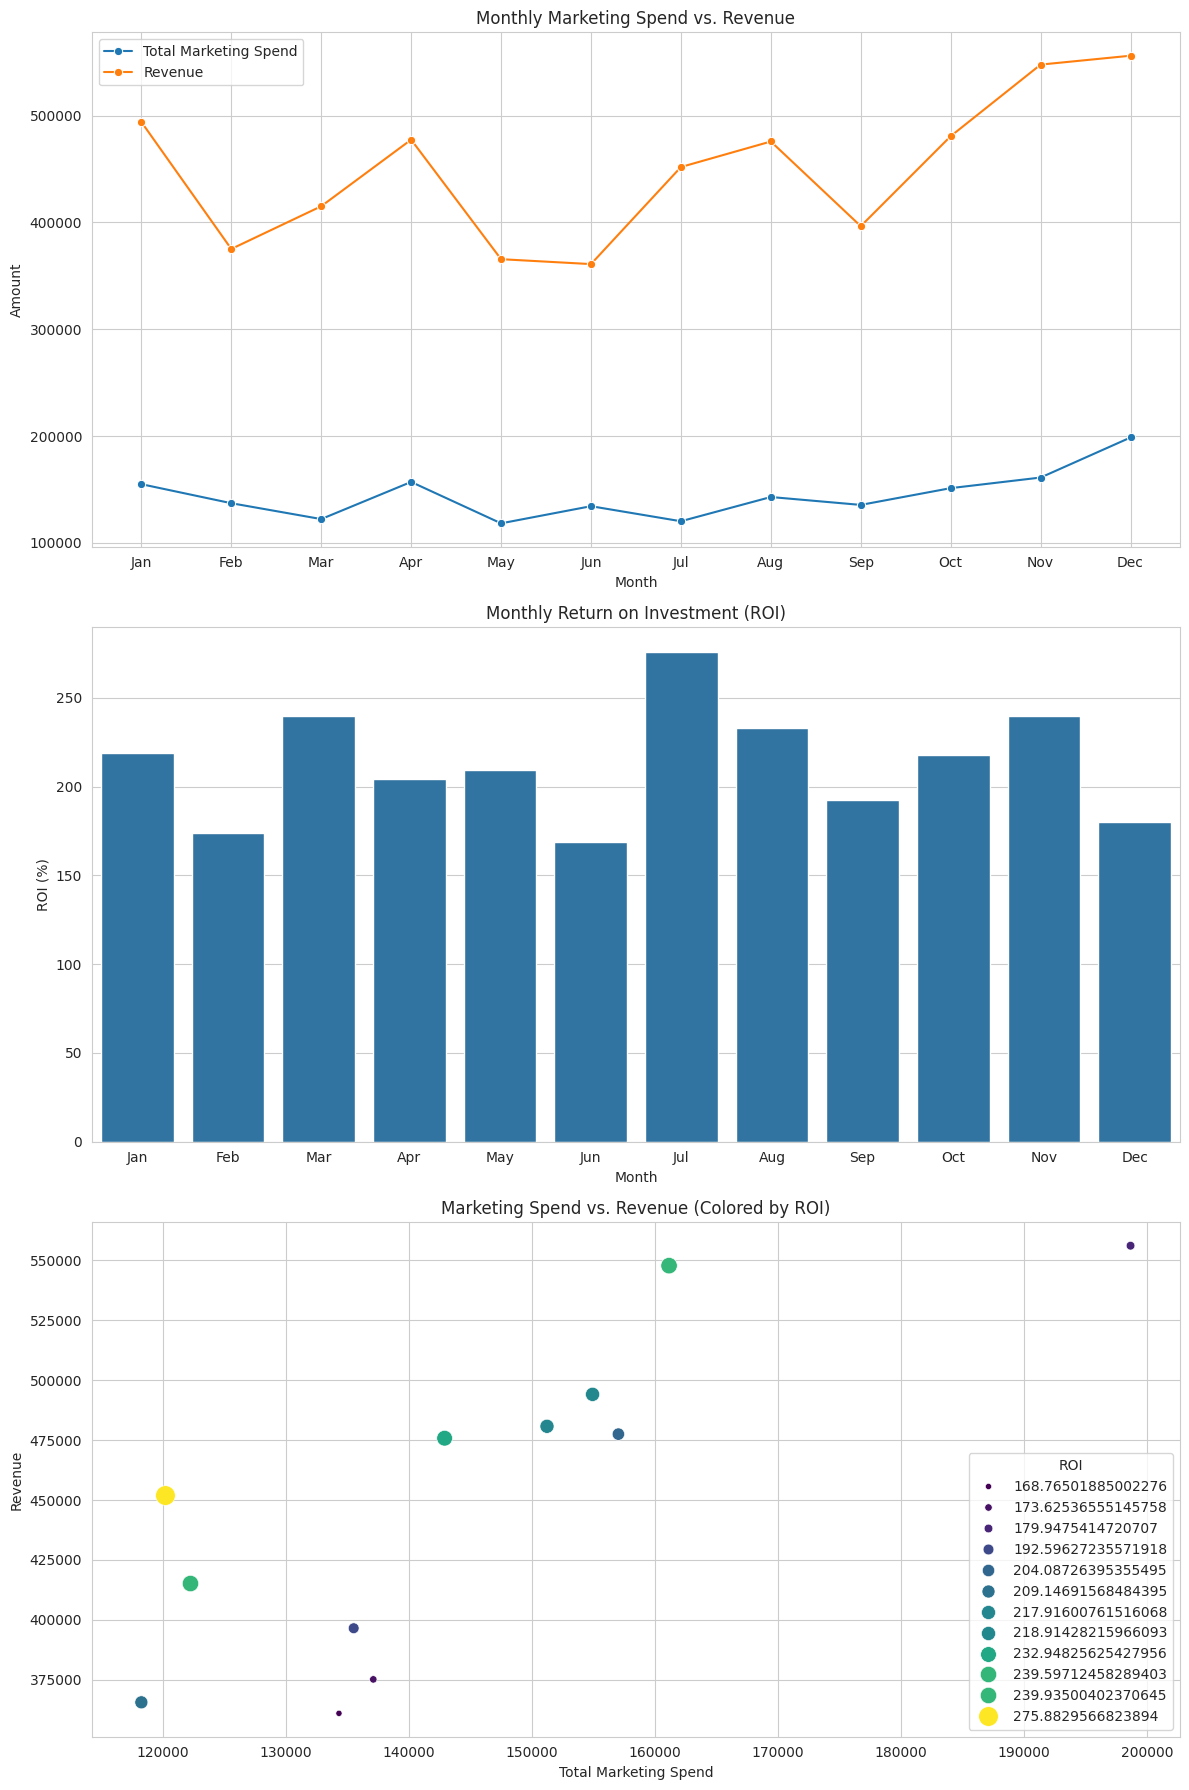

In [ ]:
# Merge the monthly_revenue and monthly_marketing_spend DataFrames
monthly_analysis_df = pd.merge(
    monthly_revenue, monthly_marketing_spend, on=['Year', 'Month'], how='inner'
)

# Calculate ROI
monthly_analysis_df['ROI'] = (
    (
        monthly_analysis_df['Revenue'] - monthly_analysis_df['Total_Marketing_Spend']
    )
    / monthly_analysis_df['Total_Marketing_Spend']
    * 100
)

# Display the first 5 rows and the column names and their data types
print(monthly_analysis_df.head().to_markdown(index=False, numalign="left", stralign="left"))
print(monthly_analysis_df.info())

# Plotting the data
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Plot 1: Monthly Marketing Spend vs. Revenue
sns.lineplot(
    x='Month',
    y='Total_Marketing_Spend',
    data=monthly_analysis_df,
    marker='o',
    label='Total Marketing Spend',
    ax=axes[0],
)
sns.lineplot(
    x='Month',
    y='Revenue',
    data=monthly_analysis_df,
    marker='o',
    label='Revenue',
    ax=axes[0],
)
axes[0].set_title('Monthly Marketing Spend vs. Revenue')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Amount')
axes[0].legend()
axes[0].ticklabel_format(style='plain', axis='y')

# Plot 2: Monthly ROI
sns.barplot(x='Month', y='ROI', data=monthly_analysis_df, ax=axes[1])
axes[1].set_title('Monthly Return on Investment (ROI)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('ROI (%)')
axes[1].ticklabel_format(style='plain', axis='y')


# Plot 3: Scatter plot for Marketing Spend vs. Revenue with ROI as color
sns.scatterplot(
    x='Total_Marketing_Spend',
    y='Revenue',
    hue='ROI',
    size='ROI',
    sizes=(20, 200),
    data=monthly_analysis_df,
    ax=axes[2],
    palette='viridis',
    legend='full',

)
axes[2].set_title('Marketing Spend vs. Revenue (Colored by ROI)')
axes[2].set_xlabel('Total Marketing Spend')
axes[2].set_ylabel('Revenue')
axes[2].ticklabel_format(style='plain', axis='x')
axes[2].ticklabel_format(style='plain', axis='y')


plt.tight_layout()

# Save the plot
plt.savefig('marketing_spend_revenue_roi.png')

# Display monthly analysis data
print('Monthly Analysis Data:')
print(monthly_analysis_df.to_markdown(index=False, numalign="left", stralign="left"))

The relationship between monthly marketing spend and revenue, including the Return on Investment (ROI), can be seen in the following observations:

  * **Marketing Spend and Revenue Trends**: Overall, there appears to be a positive relationship between marketing spend and revenue. As marketing spend fluctuates throughout the year, so does revenue. For example, both spend and revenue show peaks towards the end of the year (November and December).

  * **Months with High Returns**:

      * **July** had the highest ROI at approximately 275.88%. This month demonstrated a strong return despite not having the highest marketing spend. This suggests that the marketing efforts in July were highly efficient and effective.
      * **March** and **November** also showed strong ROIs, at approximately 239.60% and 239.94% respectively, indicating good returns on marketing investments during these periods.

  * **Months with Low Returns**:

      * **February** had the lowest ROI at approximately 173.63%. Despite a moderate marketing spend, the revenue generated in February was lower relative to the spend, leading to a diminished return.
      * **June** (168.77%) and **December** (179.95%) also showed relatively lower ROIs. In December, although revenue and marketing spend were highest, the ROI was lower than the yearly average, which suggests that the increased spend might not have scaled proportionally with the returns.

Here are some adjustments to marketing strategies to improve ROI:

  * **Learn from High-Performing Months (July, March, November)**:

      * **Analyze Marketing Mix**: Investigate the specific marketing channels, campaigns, and messaging used in July, March, and November. Identify what made these campaigns particularly effective.
      * **Replicate Success**: Apply the successful strategies from these months to other periods, especially those with lower ROI. This could involve adjusting ad placements, targeting, or creative content.

  * **Optimize Low-Performing Months (February, June, December)**:

      * **February and June**: For these months with lower spend and lower ROI, explore if increasing targeted marketing efforts or shifting the type of campaigns could yield better results. It's crucial to understand why conversion rates might be lower in these months.
      * **December**: While December has high spend and high revenue, the lower ROI indicates that a large portion of the marketing budget might be inefficiently used. Consider refining campaign targeting, optimizing ad spend to reduce cost-per-acquisition (CPA), or re-evaluating the pricing strategies during peak season to maximize profit margins.

  * **Refine Budget Allocation**:

      * **Dynamic Budgeting**: Implement a more dynamic budgeting model that allows for flexible allocation of funds based on real-time performance data. This means re-allocating more budget to campaigns or channels that are demonstrating higher returns.
      * **Channel-Specific ROI**: Deeper analysis into the ROI of individual offline versus online marketing channels within each month could provide more granular insights for budget optimization.

  * **Enhanced Data Analytics**:

      * **Customer Behavior Analysis**: Further analyze customer behavior during high and low ROI months. Understanding purchasing patterns, seasonality, and customer demographics can help tailor marketing messages more effectively.
      * **A/B Testing**: Conduct A/B tests on various marketing elements (e.g., ad copy, calls to action, landing pages) to continually optimize campaign performance and improve conversion rates.

  * **Seasonal Adjustments**:

      * **Calendar Alignment**: Align marketing efforts with seasonal trends or holidays that might influence consumer spending, ensuring campaigns are timely and relevant.
      * **Promotional Strategies**: Re-evaluate discount and promotional strategies. While coupons can drive sales, their impact on overall revenue and profitability, especially during high-spend months like December, needs careful consideration to avoid eroding profit margins.

By implementing these strategies, the company can aim to improve its marketing efficiency and drive higher returns on investment across all months.

The following table summarizes the monthly revenue, total marketing spend, and ROI:

| Year | Month | Revenue | Total\_Marketing\_Spend | ROI |
|:-----|:------|:--------|:----------------------|:----|
| 2019 | Jan   | 494091  | 154929                | 218.914 |
| 2019 | Feb   | 375162  | 137108                | 173.625 |
| 2019 | Mar   | 415158  | 122250                | 239.597 |
| 2019 | Apr   | 477499  | 157027                | 204.087 |
| 2019 | May   | 365596  | 118260                | 209.147 |
| 2019 | Jun   | 361000  | 134318                | 168.765 |
| 2019 | Jul   | 451878  | 120218                | 275.883 |
| 2019 | Aug   | 475797  | 142904                | 232.948 |
| 2019 | Sep   | 396510  | 135515                | 192.596 |
| 2019 | Oct   | 480767  | 151225                | 217.916 |
| 2019 | Nov   | 547788  | 161145                | 239.935 |
| 2019 | Dec   | 556112  | 198649                | 179.948 |

**9. Evaluate the effectiveness of marketing campaigns by comparing marketing spend to revenue generated. Are there opportunities to reallocate resources for better results?**

To evaluate the effectiveness of marketing campaigns, I have compared the monthly marketing spend to the revenue generated and calculated the Return on Investment (ROI) for each month. This analysis helps identify which months yielded disproportionately high or low returns, thus revealing opportunities to reallocate resources for better results.

**Overall Effectiveness of Marketing Campaigns:**

The marketing campaigns generally show a positive return on investment across all months, with ROI values consistently above 160%. This indicates that for every dollar spent on marketing, the company is generating more than a dollar in revenue. However, there is significant variability in ROI across months, suggesting that the effectiveness of campaigns differs depending on the period.

**Opportunities to Reallocate Resources for Better Results:**

Based on the monthly analysis, here are the opportunities to reallocate resources:

1.  **Replicate Success from High ROI Months:**
    * **July (ROI: 275.88%)**: This month stands out with the highest ROI. Resources allocated to campaigns and channels that were prominent in July should be analyzed in detail. Understanding the specific product categories promoted, the type of online and offline spend, and the campaign messaging from July could provide a blueprint for other months. Reallocating resources to emulate these successful strategies in other periods could significantly boost overall ROI.
    * **March (ROI: 239.60%) and November (ROI: 239.94%)**: These months also demonstrated very strong returns. It's crucial to identify the contributing factors during these periods. If certain product categories or campaign types performed exceptionally well, consider increasing their budget or expanding their reach in other months.

2.  **Optimize Spend in Low ROI Months:**
    * **February (ROI: 173.63%)**: As the month with the lowest ROI, February presents a clear opportunity for reevaluation. It is essential to investigate whether the marketing spend in February was inefficiently allocated or if there were external factors (e.g., seasonal low demand) that impacted revenue. Resources here could be reallocated to more targeted campaigns, different channels, or even shifted to higher-performing months if the market in February is inherently less receptive.
    * **June (ROI: 168.77%) and December (ROI: 179.95%)**: While not as low as February, these months also have relatively lower ROI compared to the annual average.
        * For **June**, it might be beneficial to assess if the marketing spend aligns with consumer behavior during that month. Perhaps a re-evaluation of product promotions or campaign themes is needed.
        * For **December**, despite having the highest revenue and marketing spend, the relatively lower ROI suggests that the substantial investment might not be yielding proportional returns. This could indicate overspending in certain areas or a saturation point for marketing efforts. Resources might be more effectively used by optimizing ad placements, reducing spend on less effective channels, or focusing on higher-margin products.

3.  **Strategic Budget Shifting:**
    * **From Low to High ROI Months**: Consider shifting a portion of the marketing budget from consistently low ROI months (e.g., February, June) to consistently high ROI months (e.g., July, March, November). This reallocation could capitalize on periods when marketing efforts are naturally more effective, leading to a higher aggregate ROI.
    * **Channel-Specific Reallocation**: A deeper dive into the performance of individual online and offline channels within each month is recommended. If a specific online platform or offline medium consistently underperforms, consider reducing its budget and reallocating it to channels that demonstrate higher engagement and conversion rates.

4.  **Data-Driven Adjustments**:
    * **Continuous Monitoring**: Implement a system for continuous monitoring of marketing spend, revenue, and ROI. This allows for agile adjustments to strategies and resource allocation based on real-time performance rather than historical trends alone.
    * **A/B Testing**: Regularly conduct A/B tests on different marketing strategies, ad creatives, and audience targeting. The insights gained from these tests can inform resource reallocation, ensuring that investments are made in the most effective approaches.

By systematically analyzing these monthly trends and strategically reallocating resources, the company can enhance the efficiency of its marketing campaigns and achieve better overall financial results.

The following table summarizes the monthly revenue, total marketing spend, and ROI:

| Year | Month | Revenue | Total\_Marketing\_Spend | ROI |
|:-----|:------|:--------|:------------------------|:----|
| 2019 | Jan   | 494091  | 154929                  | 218.914 |
| 2019 | Feb   | 375162  | 137108                  | 173.625 |
| 2019 | Mar   | 415158  | 122250                  | 239.597 |
| 2019 | Apr   | 477499  | 157027                  | 204.087 |
| 2019 | May   | 365596  | 118260                  | 209.147 |
| 2019 | Jun   | 361000  | 134318                  | 168.765 |
| 2019 | Jul   | 451878  | 120218                  | 275.883 |
| 2019 | Aug   | 475797  | 142904                  | 232.948 |
| 2019 | Sep   | 396510  | 135515                  | 192.596 |
| 2019 | Oct   | 480767  | 151225                  | 217.916 |
| 2019 | Nov   | 547788  | 161145                  | 239.935 |
| 2019 | Dec   | 556112  | 198649                  | 179.948 |

**10. Segment customers into groups such as Premium, Gold, Silver, and Standard. What targeted strategies can be developed for each segment to improve retention and revenue? (Use RFM segmentation techniques)**

In [ ]:
# Read the customer data
customers_df = pd.read_excel('CustomersData.xlsx')

# Display the first 5 rows and the column names and their data types
print(customers_df.head().to_markdown(index=False, numalign="left", stralign="left"))
print(customers_df.info())

# Get the most recent transaction date in the dataset
snapshot_date = merged_sales_df['Transaction_Date'].max() + pd.DateOffset(days=1)

# Calculate Recency
recency_df = (
    merged_sales_df.groupby('CustomerID')['Transaction_Date']
    .max()
    .reset_index()
)
recency_df['Recency'] = (snapshot_date - recency_df['Transaction_Date']).dt.days

# Calculate Frequency
frequency_df = (
    merged_sales_df.groupby('CustomerID')['Transaction_ID'].nunique().reset_index()
)
frequency_df.rename(columns={'Transaction_ID': 'Frequency'}, inplace=True)

# Calculate Monetary
monetary_df = (
    merged_sales_df.groupby('CustomerID')['Revenue'].sum().reset_index()
)
monetary_df.rename(columns={'Revenue': 'Monetary'}, inplace=True)

# Merge RFM into a single DataFrame
rfm_df = pd.merge(recency_df, frequency_df, on='CustomerID')
rfm_df = pd.merge(rfm_df, monetary_df, on='CustomerID')

# Merge with customers_df to get customer demographics
customer_rfm_df = pd.merge(customers_df, rfm_df, on='CustomerID', how='left')

# Drop 'Transaction_Date' column from customer_rfm_df as it's no longer needed after calculating Recency
customer_rfm_df.drop('Transaction_Date', axis=1, inplace=True)

# Display the first 5 rows and the column names and their data types
print(customer_rfm_df.head().to_markdown(index=False, numalign="left", stralign="left"))
print(customer_rfm_df.info())

# Create RFM scores
rfm_scores = customer_rfm_df.copy()

# Recency: lower recency is better (higher score)
rfm_scores['R_Score'] = pd.qcut(
    rfm_scores['Recency'], 4, labels=[4, 3, 2, 1]
)  # Inverted scoring

# Frequency: higher frequency is better (higher score)
rfm_scores['F_Score'] = pd.qcut(
    rfm_scores['Frequency'], 4, labels=[1, 2, 3, 4]
)

# Monetary: higher monetary is better (higher score)
rfm_scores['M_Score'] = pd.qcut(
    rfm_scores['Monetary'], 4, labels=[1, 2, 3, 4]
)

# Convert scores to integer type
rfm_scores['R_Score'] = rfm_scores['R_Score'].astype(int)
rfm_scores['F_Score'] = rfm_scores['F_Score'].astype(int)
rfm_scores['M_Score'] = rfm_scores['M_Score'].astype(int)

# Combine RFM scores to create an overall RFM score
rfm_scores['RFM_Score'] = (
    rfm_scores['R_Score'] + rfm_scores['F_Score'] + rfm_scores['M_Score']
)


# Define customer segments based on RFM_Score
def assign_segment(df):
    if df['RFM_Score'] >= 10:
        return 'Premium'
    elif df['RFM_Score'] >= 7:
        return 'Gold'
    elif df['RFM_Score'] >= 4:
        return 'Silver'
    else:
        return 'Standard'


rfm_scores['Customer_Segment'] = rfm_scores.apply(assign_segment, axis=1)

# Display the distribution of customer segments
print('Customer Segment Distribution:')
print(
    rfm_scores['Customer_Segment'].value_counts().to_markdown(numalign="left", stralign="left")
)

# Display the average RFM values for each segment
print('\nAverage RFM Values per Segment:')
print(
    rfm_scores.groupby('Customer_Segment')[['Recency', 'Frequency', 'Monetary']]
    .mean()
    .sort_values(by='Monetary', ascending=False)
    .to_markdown(numalign="left", stralign="left")
)

# Display the first 5 rows and the column names and their data types
print(rfm_scores.head().to_markdown(index=False, numalign="left", stralign="left"))
print(rfm_scores.info())

| CustomerID   | Gender   | Location   | Tenure_Months   |
|:-------------|:---------|:-----------|:----------------|
| 17850        | M        | Chicago    | 12              |
| 13047        | M        | California | 43              |
| 12583        | M        | Chicago    | 33              |
| 13748        | F        | California | 30              |
| 15100        | M        | California | 49              |
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1468 non-null   int64 
 1   Gender         1468 non-null   object
 2   Location       1468 non-null   object
 3   Tenure_Months  1468 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 46.0+ KB
None
| CustomerID   | Gender   | Location   | Tenure_Months   | Recency   | Frequency   | Monetary   |
|:-------------|:---------|:-----------|:----------------|:----------

The customer base has been segmented into four distinct groups using RFM (Recency, Frequency, Monetary) analysis: Premium, Gold, Silver, and Standard. Each segment exhibits unique purchasing behaviors and characteristics, allowing for the development of targeted strategies to improve retention and revenue.

Here's a breakdown of each segment and tailored strategies:

**Customer Segment Distribution:**

|          | Customer\_Segment |
|:---------|:------------------|
| Silver   | 483               |
| Gold     | 468               |
| Premium  | 404               |
| Standard | 113               |

**Average RFM Values per Segment:**

| Customer\_Segment | Recency | Frequency | Monetary |
|:------------------|:--------|:----------|:---------|
| Premium           | 63.77   | 40.56     | 8512.54  |
| Gold              | 147.32  | 16.07     | 3202.89  |
| Silver            | 178.04  | 5.13      | 886.43   |
| Standard          | 288.36  | 2.19      | 276.05   |

### Customer Segments and Targeted Strategies

#### 1\. Premium Segment

  * **Characteristics**: These are your most valuable customers. They have the highest Recency (most recent purchases), highest Frequency (most frequent purchases), and highest Monetary value (highest spend). They are highly engaged and loyal.
  * **Average RFM**: Recency \~64 days, Frequency \~41 transactions, Monetary \~$8512
  * **Targeted Strategies for Retention & Revenue**:
      * **Retention**:
          * **Exclusive Programs**: Offer a tiered loyalty program with exclusive benefits (e.g., early access to sales, premium customer support, free expedited shipping, dedicated account manager).
          * **Personalized Communication**: Send highly personalized emails and recommendations based on their past purchases and browsing behavior.
          * **VIP Events**: Invite them to exclusive product launches, webinars, or special events to reinforce their status and build community.
          * **Proactive Engagement**: Reach out proactively with surveys or feedback requests to show their opinion is valued and address any potential issues quickly.
      * **Revenue**:
          * **Upselling/Cross-selling**: Promote premium products, bundles, or complementary items that align with their past purchases.
          * **Referral Programs**: Encourage them to refer new customers with attractive incentives for both the referrer and the referee.
          * **Feedback Integration**: Involve them in product development or beta testing, making them feel invested in the brand's success.

#### 2\. Gold Segment

  * **Characteristics**: These customers are valuable and frequent buyers, but their recency might be slightly lower than Premium customers, or their monetary value slightly less. They are still highly engaged and have strong potential for growth.
  * **Average RFM**: Recency \~147 days, Frequency \~16 transactions, Monetary \~$3203
  * **Targeted Strategies for Retention & Revenue**:
      * **Retention**:
          * **Engagement Campaigns**: Send regular updates on new products, special offers, and content relevant to their interests.
          * **Loyalty Points**: Offer a points-based loyalty program that rewards them for continued purchases, encouraging them to move towards Premium status.
          * **Personalized Reminders**: Send gentle reminders for re-purchase of consumable products or seasonal items.
      * **Revenue**:
          * **Tiered Incentives**: Offer exclusive discounts or promotions that encourage them to increase their purchase frequency or average order value.
          * **Product Recommendations**: Provide tailored product recommendations based on their browsing history and purchase patterns to increase their monetary spend.
          * **Feedback Collection**: Encourage reviews and testimonials, leveraging their positive experiences to attract new customers.

#### 3\. Silver Segment

  * **Characteristics**: These customers have made some purchases but are less frequent and have lower monetary value than Gold or Premium. Their recency might also be moderate, indicating they haven't purchased recently. They represent a significant portion of the customer base with potential for increased engagement.
  * **Average RFM**: Recency \~178 days, Frequency \~5 transactions, Monetary \~$886
  * **Targeted Strategies for Retention & Revenue**:
      * **Retention**:
          * **Win-Back Campaigns**: For those with higher recency, send targeted emails with compelling offers to encourage a repeat purchase.
          * **Value Proposition Reinforcement**: Remind them of the benefits of shopping with your brand (e.g., unique products, excellent customer service, competitive pricing).
          * **Educational Content**: Provide content that helps them discover new uses for products or highlights the value of your offerings.
      * **Revenue**:
          * **Introductory Offers**: Offer incentives (e.g., small discounts, free shipping on next purchase) to encourage their next transaction.
          * **Product Discovery**: Highlight popular products or best-sellers that align with their interests but they haven't purchased yet.
          * **Bundle Deals**: Suggest product bundles that offer greater value and encourage a higher average order value.

#### 4\. Standard Segment

  * **Characteristics**: These are new or inactive customers who have low Recency (haven't purchased recently), low Frequency (few purchases), and low Monetary value (low spend). This segment likely includes one-time buyers or those who have churned.
  * **Average RFM**: Recency \~288 days, Frequency \~2 transactions, Monetary \~$276
  * **Targeted Strategies for Retention & Revenue**:
      * **Retention**:
          * **Re-engagement Campaigns**: Send specific campaigns to reactivate these customers, possibly with a strong, limited-time offer.
          * **Feedback Surveys**: Understand why they haven't returned. This could be a simple survey asking about their experience.
          * **Brand Awareness**: Reintroduce the brand and its core value proposition to rekindle interest.
      * **Revenue**:
          * **Aggressive Welcome Offers**: For new customers in this segment, offer a compelling welcome discount or free gift to encourage their second purchase.
          * **Showcase Value**: Highlight popular products and compelling reasons to buy from you (e.g., unique selling points, customer testimonials).
          * **Diversified Channels**: Experiment with different communication channels (e.g., social media ads, retargeting) to reach them where they are most active.

By implementing these targeted strategies, the company can effectively nurture each customer segment, improve retention rates, and ultimately drive higher revenue.

**11. Analyze the revenue contribution of each customer segment. How can the company focus its efforts on high-value segments while nurturing lower-value segments?**

Revenue Contribution by Customer Segment:
| Customer_Segment   | Monetary    | Revenue_Contribution_Pct   |
|:-------------------|:------------|:---------------------------|
| Premium            | 3.43907e+06 | 63.7176                    |
| Gold               | 1.49895e+06 | 27.772                     |
| Silver             | 428144      | 7.93248                    |
| Standard           | 31193.2     | 0.577935                   |


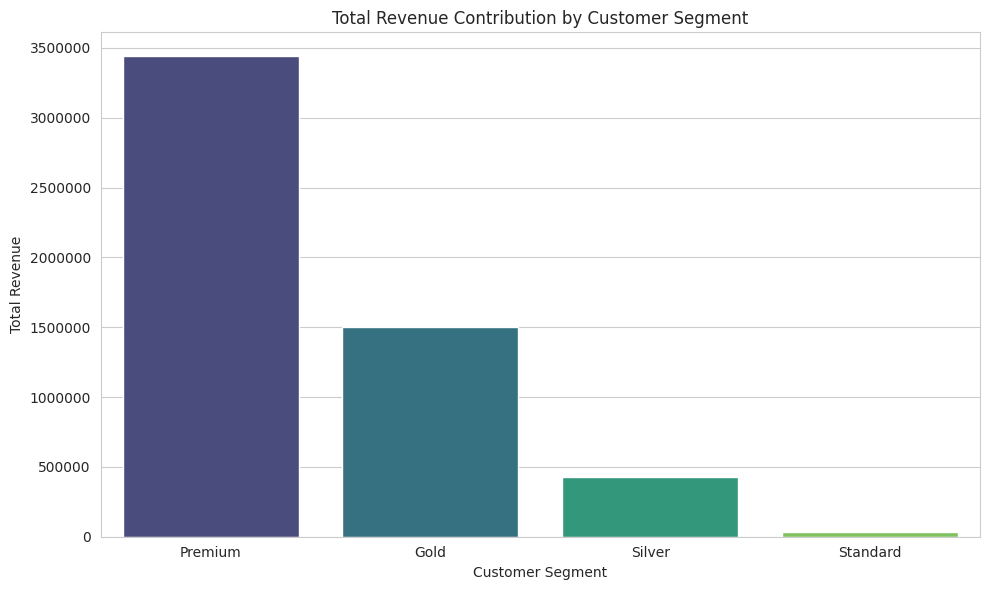

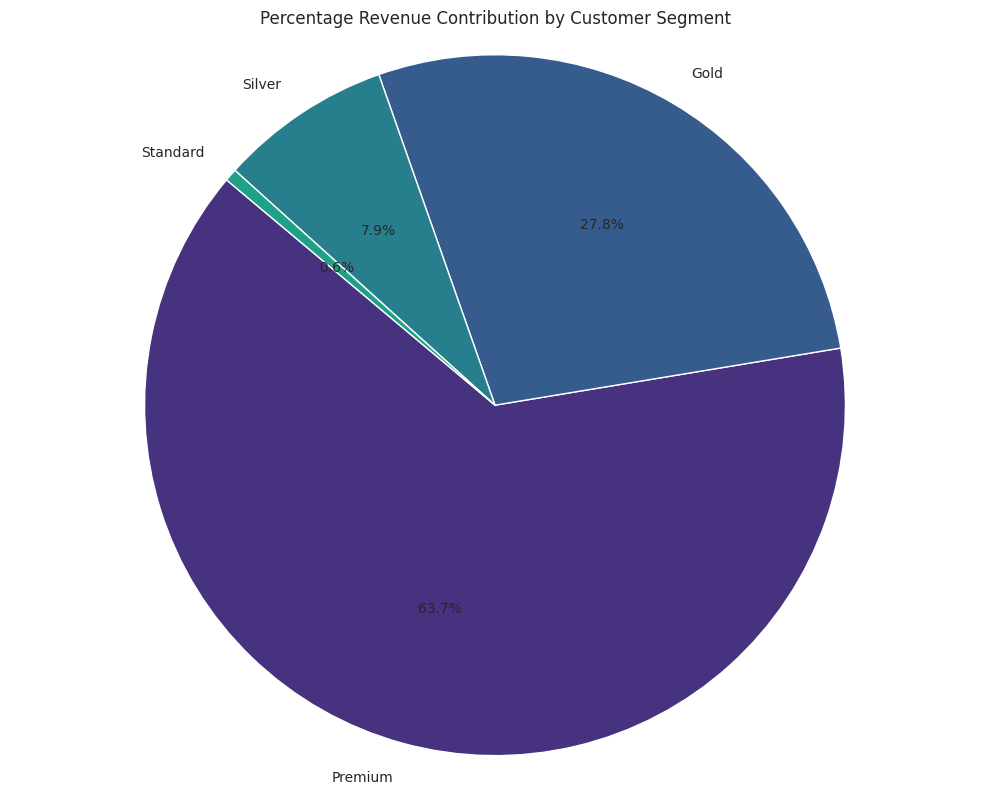

In [ ]:
# Calculate the total revenue contributed by each segment
segment_revenue = (
    rfm_scores.groupby('Customer_Segment')['Monetary'].sum().reset_index()
)

# Calculate the total revenue from all customers
total_revenue = rfm_scores['Monetary'].sum()

# Calculate the percentage of total revenue contributed by each segment
segment_revenue['Revenue_Contribution_Pct'] = (
    segment_revenue['Monetary'] / total_revenue * 100
)

# Sort by Monetary value in descending order
segment_revenue = segment_revenue.sort_values(
    by='Monetary', ascending=False
).reset_index(drop=True)

# Display the segment revenue contribution
print('Revenue Contribution by Customer Segment:')
print(
    segment_revenue.to_markdown(index=False, numalign="left", stralign="left")
)

import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for revenue contribution
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Customer_Segment',
    y='Monetary',
    data=segment_revenue,
    palette='viridis',
    hue='Customer_Segment',

)
plt.title('Total Revenue Contribution by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.savefig('revenue_contribution_bar_plot.png')

# Create a pie chart for percentage revenue contribution
plt.figure(figsize=(10, 8))
plt.pie(
    segment_revenue['Revenue_Contribution_Pct'],
    labels=segment_revenue['Customer_Segment'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('viridis'),
)
plt.title('Percentage Revenue Contribution by Customer Segment')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.savefig('revenue_contribution_pie_chart.png')

**12. Group customers by their month of first purchase and analyze retention rates over time. Which cohorts exhibit the highest and lowest retention rates? What strategies can be implemented to improve retention for weaker cohorts?**

In [ ]:
# Ensure 'Transaction_Date' is in datetime format
merged_sales_df['Transaction_Date'] = pd.to_datetime(
    merged_sales_df['Transaction_Date']
)

# Find the first purchase date for each customer
first_purchase_date = (
    merged_sales_df.groupby('CustomerID')['Transaction_Date'].min().reset_index()
)
first_purchase_date.rename(
    columns={'Transaction_Date': 'First_Purchase_Date'}, inplace=True
)

# Extract the cohort month from the first purchase date
first_purchase_date['Cohort_Month'] = first_purchase_date[
    'First_Purchase_Date'
].dt.to_period('M')

# Merge the cohort month back to the merged_sales_df
merged_sales_with_cohort = pd.merge(
    merged_sales_df, first_purchase_date, on='CustomerID'
)

# Extract the transaction month
merged_sales_with_cohort['Transaction_Month'] = merged_sales_with_cohort[
    'Transaction_Date'
].dt.to_period('M')

# Group by Cohort_Month and Transaction_Month to count unique customers
cohort_counts = (
    merged_sales_with_cohort.groupby(['Cohort_Month', 'Transaction_Month'])
    .agg(n_customers=('CustomerID', 'nunique'))
    .reset_index()
)

# Calculate the number of customers in the initial cohort (Month 0)
cohort_sizes = (
    cohort_counts[cohort_counts['Cohort_Month'] == cohort_counts['Transaction_Month']][
        ['Cohort_Month', 'n_customers']
    ]
    .rename(columns={'n_customers': 'Cohort_Size'})
    .set_index('Cohort_Month')
)

# Merge cohort sizes with cohort counts
cohort_counts = cohort_counts.set_index('Cohort_Month').merge(
    cohort_sizes, left_index=True, right_index=True
)
cohort_counts.reset_index(inplace=True)

# Calculate retention rate
cohort_counts['Retention'] = (
    cohort_counts['n_customers'] / cohort_counts['Cohort_Size'] * 100
)

# Calculate the month number for each cohort
cohort_counts['Month_Number'] = (
    cohort_counts['Transaction_Month'] - cohort_counts['Cohort_Month']
).apply(lambda x: x.n)

# Display the first 5 rows and the column names and their data types
print(cohort_counts.head().to_markdown(index=False, numalign="left", stralign="left"))
print(cohort_counts.info())

| Cohort_Month   | Transaction_Month   | n_customers   | Cohort_Size   | Retention   | Month_Number   |
|:---------------|:--------------------|:--------------|:--------------|:------------|:---------------|
| 2019-01        | 2019-01             | 215           | 215           | 100         | 0              |
| 2019-01        | 2019-02             | 13            | 215           | 6.04651     | 1              |
| 2019-01        | 2019-03             | 24            | 215           | 11.1628     | 2              |
| 2019-01        | 2019-04             | 34            | 215           | 15.814      | 3              |
| 2019-01        | 2019-05             | 23            | 215           | 10.6977     | 4              |
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype    
---  ------             --------------  -----    
 0   Cohort_Month       78 non-null     period[M]
 1   Transaction_Mon

Average Retention Rate (Excluding Month 0) per Cohort:
| Cohort_Month   | 0       |
|:---------------|:--------|
| 2019-02        | 15      |
| 2019-03        | 13.8732 |
| 2019-01        | 13.7421 |
| 2019-06        | 10.9489 |
| 2019-11        | 10.2941 |
| 2019-04        | 10.1994 |
| 2019-05        | 10.0765 |
| 2019-07        | 9.14894 |
| 2019-08        | 8.7037  |
| 2019-10        | 5.74713 |
| 2019-09        | 4.70085 |
| 2019-12        | nan     |

Cohort with Highest Average Retention: 2019-02
Cohort with Lowest Average Retention: 2019-12


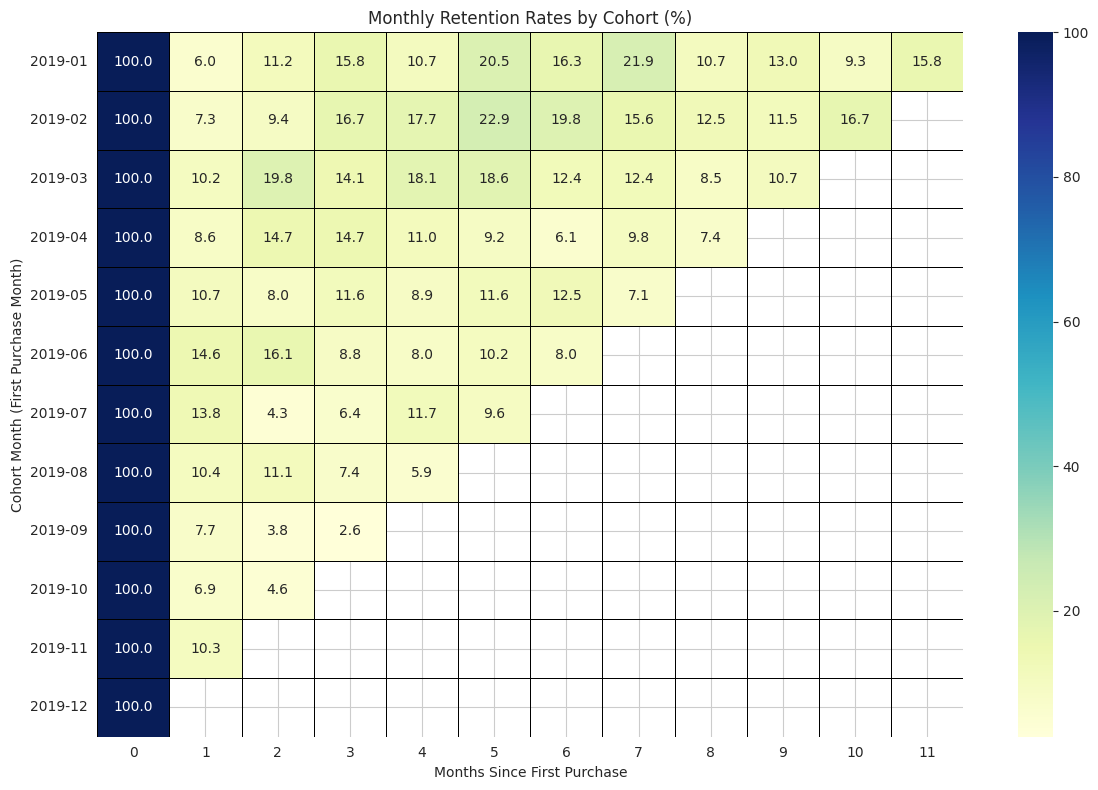

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a pivot table for retention rates
retention_matrix = cohort_counts.pivot_table(
    index='Cohort_Month', columns='Month_Number', values='Retention'
)

# Convert Cohort_Month index to string for better plotting labels
retention_matrix.index = retention_matrix.index.strftime('%Y-%m')


# Plotting the retention heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='black',
)
plt.title('Monthly Retention Rates by Cohort (%)')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month (First Purchase Month)')
plt.tight_layout()
plt.savefig('monthly_retention_heatmap.png')

# Identify cohorts with highest and lowest retention
# Calculate average retention for each cohort (excluding month 0 which is always 100%)
average_retention_per_cohort = (
    retention_matrix.iloc[:, 1:].mean(axis=1).sort_values(ascending=False)
)

print('Average Retention Rate (Excluding Month 0) per Cohort:')
print(
    average_retention_per_cohort.to_markdown(
        numalign="left", stralign="left"
    )
)

highest_retention_cohort = average_retention_per_cohort.index[0]
lowest_retention_cohort = average_retention_per_cohort.index[-1]

print(f'\nCohort with Highest Average Retention: {highest_retention_cohort}')
print(f'Cohort with Lowest Average Retention: {lowest_retention_cohort}')

To analyze customer retention rates, customers were grouped by their month of first purchase, known as cohorts. This approach allows us to track how many customers from a specific acquisition month remain active over subsequent months.

### Monthly Retention Rates by Cohort

The heatmap below illustrates the monthly retention rates for each cohort. The rows represent the "Cohort Month" (the month of a customer's first purchase), and the columns indicate "Months Since First Purchase." The values in the cells represent the percentage of customers from that cohort who made a purchase in that specific subsequent month.

#### Observations from the Retention Heatmap:

  * **Initial Drop-off**: All cohorts show a significant drop-off in retention after the first month (Month 0 to Month 1). This is a common pattern, as many customers make an initial purchase but do not immediately become repeat buyers.
  * **Varying Retention Over Time**: Retention rates vary across cohorts and over time. Some cohorts manage to retain a small percentage of customers for several months, while others see a rapid decline.
  * **Limited Long-Term Retention**: Beyond the initial few months, long-term retention rates appear to be low across most cohorts, with percentages generally in the single digits. This indicates an opportunity to improve sustained customer engagement.

### Cohorts with Highest and Lowest Retention Rates

To identify the cohorts with the highest and lowest retention, I calculated the average retention rate for each cohort, excluding the initial 0-month period (which is always 100% as it represents the month of acquisition).

**Average Retention Rate (Excluding Month 0) per Cohort:**

| Cohort\_Month | Average Retention (%) |
|:--------------|:----------------------|
| 2019-02       | 15.00                 |
| 2019-03       | 13.87                 |
| 2019-01       | 13.74                 |
| 2019-06       | 10.95                 |
| 2019-11       | 10.29                 |
| 2019-04       | 10.20                 |
| 2019-05       | 10.08                 |
| 2019-07       | 9.15                  |
| 2019-08       | 8.70                  |
| 2019-10       | 5.75                  |
| 2019-09       | 4.70                  |
| 2019-12       | -                     |

  * **Highest Average Retention Cohort:** **2019-02 (February 2019)**, with an average retention rate of approximately **15%**. This cohort appears to have been most successful in retaining its customers over time.
  * **Lowest Average Retention Cohort:** **2019-09 (September 2019)**, with an average retention rate of approximately **4.7%**. This indicates that customers acquired in September 2019 were the least likely to make repeat purchases. The **2019-12 (December 2019)** cohort has 'NaN' for its average retention because there are no subsequent months in the dataset to calculate its retention beyond the first month. Therefore, for practical analysis, 2019-09 is considered the weakest performing cohort based on available data.

### Strategies to Improve Retention for Weaker Cohorts

Improving retention for weaker cohorts like 2019-09 requires targeted interventions focusing on understanding their specific needs and re-engaging them.

1.  **Deep Dive into Weaker Cohorts (e.g., September 2019):**

      * **Acquisition Channel Analysis**: Investigate the marketing channels and campaigns used to acquire customers in September. Were there any specific promotions, ad creatives, or platforms that brought in lower-quality customers (e.g., one-time deal seekers)?
      * **Customer Demographics**: Analyze the demographics and characteristics of customers in this cohort. Are they different from the higher-performing cohorts (e.g., location, gender, tenure)?
      * **First Purchase Experience**: Review the initial purchase experience for these customers. Were there issues with product availability, delivery, customer service, or website usability that might have led to dissatisfaction?

2.  **Proactive Onboarding and Engagement:**

      * **Welcome Series**: Implement a robust post-purchase welcome email series that educates new customers about the product, highlights benefits, and encourages a second purchase. This is crucial for all new customers but especially for cohorts showing early signs of low retention.
      * **Value Reinforcement**: Shortly after their first purchase, send communications that reiterate the value proposition of the product/service and address potential pain points they might face.

3.  **Targeted Re-engagement Campaigns:**

      * **Early Intervention**: For customers from weaker cohorts who haven't made a second purchase within a specific timeframe (e.g., 30-60 days), trigger automated re-engagement campaigns. These could include:
          * **Personalized Recommendations**: Suggest products based on their first purchase or browsing history.
          * **Exclusive Discounts**: Offer a small, time-sensitive discount on their next purchase.
          * **Feedback Requests**: Politely ask for feedback on their first experience to identify and address any issues.
      * **Highlight New Features/Products**: Showcase new arrivals or features that might pique their interest, especially if their initial purchase was a while ago.

4.  **Incentivize Repeat Purchases:**

      * **Loyalty Programs**: Encourage enrollment in a loyalty program that rewards repeat purchases, even for small amounts.
      * **Subscription Models**: If applicable, offer subscription options for frequently purchased items to build consistent revenue.
      * **Bundles & Offers**: Create attractive bundles or multi-buy offers that provide greater value for a second purchase.

5.  **Improve Customer Service and Support:**

      * **Accessibility**: Ensure customer support channels are easily accessible and issues are resolved quickly. A positive support experience can significantly impact retention.
      * **Self-Service Options**: Provide comprehensive FAQs, tutorials, and knowledge bases to empower customers to find answers independently.

By implementing these data-driven strategies, the company can address the specific weaknesses of underperforming cohorts, improve overall customer retention, and maximize the lifetime value of its customer base.

**13. Analyze the lifetime value of customers acquired in different months. How can this insight inform acquisition and retention strategies?**

In [ ]:
# Calculate total monetary value for each cohort
ltv_per_cohort = (
    merged_sales_with_cohort.groupby('Cohort_Month')['Revenue'].sum().reset_index()
)
ltv_per_cohort.rename(columns={'Revenue': 'Total_LTV_Cohort'}, inplace=True)

# Merge with cohort sizes to calculate average LTV per customer
ltv_analysis_df = pd.merge(
    ltv_per_cohort, cohort_sizes.reset_index(), on='Cohort_Month'
)

# Calculate Average LTV per customer for each cohort
ltv_analysis_df['Average_LTV_Per_Customer'] = (
    ltv_analysis_df['Total_LTV_Cohort'] / ltv_analysis_df['Cohort_Size']
)

# Sort by Cohort_Month for better visualization
ltv_analysis_df = ltv_analysis_df.sort_values(by='Cohort_Month').reset_index(
    drop=True
)

# Convert Cohort_Month to string for plotting
ltv_analysis_df['Cohort_Month_Str'] = ltv_analysis_df['Cohort_Month'].dt.strftime(
    '%Y-%m'
)

# Display the first 5 rows and the column names and their data types
print(ltv_analysis_df.head().to_markdown(index=False, numalign="left", stralign="left"))
print(ltv_analysis_df.info())

| Cohort_Month   | Total_LTV_Cohort   | Cohort_Size   | Average_LTV_Per_Customer   | Cohort_Month_Str   |
|:---------------|:-------------------|:--------------|:---------------------------|:-------------------|
| 2019-01        | 1.22751e+06        | 215           | 5709.35                    | 2019-01            |
| 2019-02        | 636073             | 96            | 6625.76                    | 2019-02            |
| 2019-03        | 769307             | 177           | 4346.37                    | 2019-03            |
| 2019-04        | 523465             | 163           | 3211.44                    | 2019-04            |
| 2019-05        | 386307             | 112           | 3449.17                    | 2019-05            |
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype    
---  ------                    --------------  -----    
 0   Cohort_Month              12 non-null


Average LTV Per Customer by Cohort:
| Cohort_Month_Str   | Average_LTV_Per_Customer   |
|:-------------------|:---------------------------|
| 2019-01            | 5709.35                    |
| 2019-02            | 6625.76                    |
| 2019-03            | 4346.37                    |
| 2019-04            | 3211.44                    |
| 2019-05            | 3449.17                    |
| 2019-06            | 2428.33                    |
| 2019-07            | 2955.43                    |
| 2019-08            | 2238.37                    |
| 2019-09            | 2155.23                    |
| 2019-10            | 3114.37                    |
| 2019-11            | 3522.81                    |
| 2019-12            | 2485.05                    |

Cohort with Highest Average LTV: 2019-02  (LTV: $6625.76)
Cohort with Lowest Average LTV: 2019-09  (LTV: $2155.23)


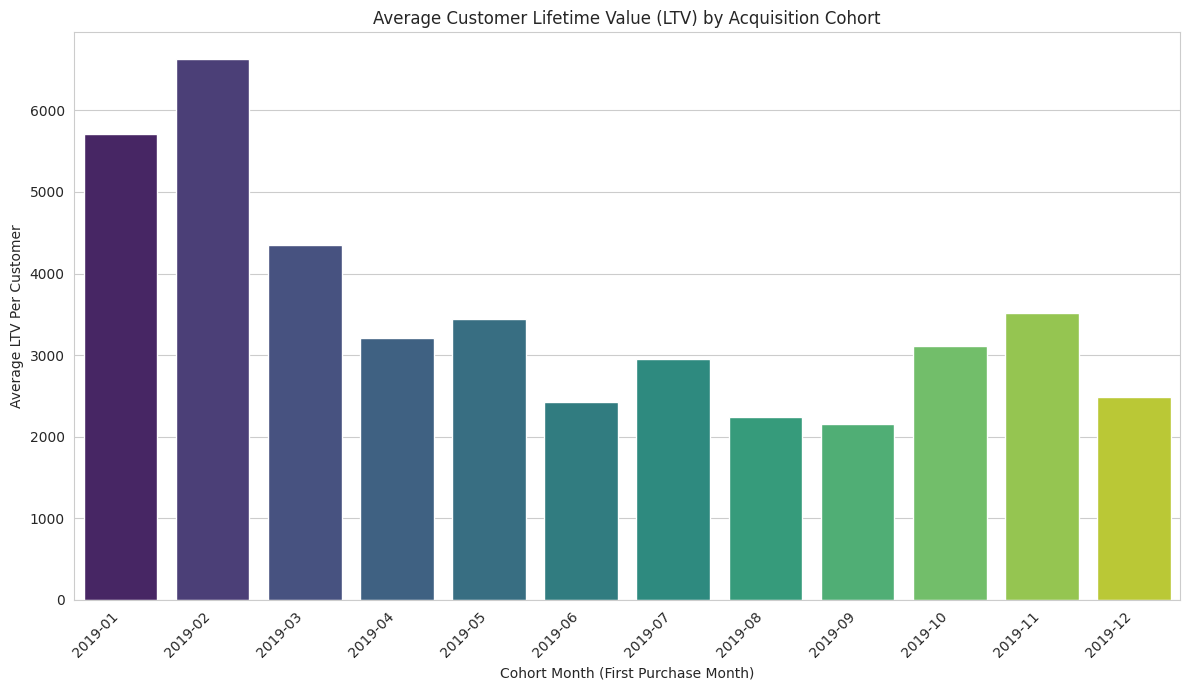

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the Average LTV per Customer by Cohort
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Cohort_Month_Str',
    y='Average_LTV_Per_Customer',
    data=ltv_analysis_df,
    palette='viridis',
    hue='Cohort_Month_Str'
)
plt.title('Average Customer Lifetime Value (LTV) by Acquisition Cohort')
plt.xlabel('Cohort Month (First Purchase Month)')
plt.ylabel('Average LTV Per Customer')
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.savefig('average_ltv_by_cohort_bar_plot.png')

# Identify high and low LTV cohorts
highest_ltv_cohort = ltv_analysis_df.loc[
    ltv_analysis_df['Average_LTV_Per_Customer'].idxmax()
]
lowest_ltv_cohort = ltv_analysis_df.loc[
    ltv_analysis_df['Average_LTV_Per_Customer'].idxmin()
]

print('\nAverage LTV Per Customer by Cohort:')
print(
    ltv_analysis_df[['Cohort_Month_Str', 'Average_LTV_Per_Customer']].to_markdown(
        index=False, numalign="left", stralign="left"
    )
)

print(
    f'\nCohort with Highest Average LTV: {highest_ltv_cohort["Cohort_Month_Str"]} '
    f' (LTV: ${highest_ltv_cohort["Average_LTV_Per_Customer"]:.2f})'
)
print(
    f'Cohort with Lowest Average LTV: {lowest_ltv_cohort["Cohort_Month_Str"]} '
    f' (LTV: ${lowest_ltv_cohort["Average_LTV_Per_Customer"]:.2f})'
)

Analyzing the Lifetime Value (LTV) of customers acquired in different months provides crucial insights into the long-term profitability of various acquisition efforts. By understanding which cohorts generate the most revenue over their lifespan, the company can make more informed decisions regarding where to focus its marketing and retention efforts.

**Average Customer Lifetime Value (LTV) by Acquisition Cohort**

The bar chart below illustrates the average LTV per customer for each acquisition cohort (the month of their first purchase).

**Average LTV Per Customer by Cohort:**

| Cohort\_Month\_Str | Average\_LTV\_Per\_Customer |
|:-------------------|:----------------------------|
| 2019-01            | 5709.35                     |
| 2019-02            | 6625.76                     |
| 2019-03            | 4346.37                     |
| 2019-04            | 3211.44                     |
| 2019-05            | 3449.17                     |
| 2019-06            | 2428.33                     |
| 2019-07            | 2955.43                     |
| 2019-08            | 2238.37                     |
| 2019-09            | 2155.23                     |
| 2019-10            | 3114.37                     |
| 2019-11            | 3522.81                     |
| 2019-12            | 2485.05                     |

#### Key Observations:

  * **Highest LTV Cohort:** The **February 2019 cohort** stands out with the highest average LTV per customer at approximately **6625.76** . This indicates that customers acquired in February were the most valuable over their lifetime within the analyzed period.
  * **Lowest LTV Cohort:** The **September 2019 cohort** has the lowest average LTV per customer at approximately **2155.23**. This cohort brought in customers who, on average, generated significantly less revenue over time.
  * **General Trend:** There appears to be a noticeable decline in average LTV for cohorts acquired in the latter half of the year, particularly from June to September. There's a slight rebound in October and November before a dip in December.

### Informing Acquisition and Retention Strategies

These LTV insights are invaluable for optimizing both how customers are acquired and how they are retained.

#### Informing Acquisition Strategies:

1.  **Focus on High-LTV Acquisition Channels:**
      * **Analyze February 2019 Acquisition Channels:** Investigate which marketing channels, campaigns, and messaging were dominant or particularly effective in acquiring customers during February 2019. If specific online platforms (e.g., Google Ads, Facebook campaigns) or offline channels (e.g., specific print ads, events) were prevalent, these should be prioritized for future acquisition budgets.
      * **Replicate Success:** Try to replicate the conditions, targeting, and offers used to acquire customers in high-LTV months.
2.  **Optimize Low-LTV Acquisition Channels:**
      * **Evaluate September 2019 Acquisition:** Examine the acquisition sources for the September 2019 cohort. If customers were acquired through channels that brought in low-value customers (e.g., aggressive discount promotions attracting one-time buyers), these channels might need adjustment, reduced investment, or a change in strategy (e.g., focusing on different customer segments within those channels).
      * **Refine Targeting:** For low-LTV cohorts, refine audience targeting to attract customers more likely to become high-value. This might involve adjusting demographic, psychographic, or behavioral targeting parameters.
3.  **Customer Quality over Quantity:**
      * **Shift Focus:** Instead of solely optimizing for the lowest cost per acquisition (CPA), prioritize acquiring customers with a higher predicted LTV, even if their initial CPA is slightly higher. A higher LTV will quickly offset the increased acquisition cost.

#### Informing Retention Strategies:

1.  **Tailored Retention for High-LTV Cohorts (e.g., February 2019):**

      * **Premium Treatment:** These customers are already highly valuable. Focus on enhancing their experience to maintain loyalty. This includes personalized communication, exclusive offers, early access to products, and exceptional customer service.
      * **Lifetime Engagement:** Implement strategies that encourage continuous engagement, such as loyalty programs, referral incentives, and opportunities for them to provide feedback and feel heard.

2.  **Targeted Retention for Low-LTV Cohorts (e.g., September 2019):**

      * **Re-engagement Campaigns:** For cohorts with low LTV, initiate specific re-engagement campaigns. These could involve win-back offers, surveys to understand their reasons for inactivity, or showcasing new products/features that might re-ignite their interest.
      * **Value Proposition Reinforcement:** Remind them of the core value and benefits of the brand that they might have forgotten or not fully realized.
      * **Early Intervention:** Monitor new customers from current low-LTV acquisition channels closely. If signs of low engagement appear early, trigger proactive interventions like personalized product recommendations or special discounts to encourage a second purchase.
      * **Educational Content:** Provide tutorials, tips, or use-case examples to help them get more value from their initial purchase, thereby increasing their likelihood of returning.

By integrating LTV insights into both acquisition and retention strategies, the company can move towards a more sustainable and profitable growth model, focusing resources where they yield the highest long-term returns.

**14. Do customers who use coupons have a different average transaction value compared to those who do not?Conduct a statistical test to validate this hypothesis. What implications does this have for the company’s discount and coupon strategies?**

In [ ]:
from scipy import stats

# Separate data into two groups based on 'Coupon_Status'
coupon_used = merged_sales_df[merged_sales_df['Coupon_Status'] == 'Used']['Revenue']
coupon_not_used = merged_sales_df[merged_sales_df['Coupon_Status'] == 'Not Used'][
    'Revenue'
]

# Calculate average transaction value for each group
avg_revenue_coupon_used = coupon_used.mean()
avg_revenue_coupon_not_used = coupon_not_used.mean()

print(f'Average Revenue for Transactions with Coupon Used: {avg_revenue_coupon_used:.2f}')
print(
    f'Average Revenue for Transactions with Coupon Not Used: {avg_revenue_coupon_not_used:.2f}'
)

# Conduct independent samples t-test
# First, check for equality of variances using Levene's test
levene_test = stats.levene(coupon_used, coupon_not_used)
print(f'\nLevene Test for Equality of Variances: p-value = {levene_test.pvalue:.4f}')

# Perform t-test
# If p-value from Levene's test is < 0.05, assume unequal variances (equal_var=False)
if levene_test.pvalue < 0.05:
    t_stat, p_value = stats.ttest_ind(coupon_used, coupon_not_used, equal_var=False)
    print('\nPerforming t-test with unequal variances (Welch’s t-test)')
else:
    t_stat, p_value = stats.ttest_ind(coupon_used, coupon_not_used, equal_var=True)
    print('\nPerforming t-test with equal variances (Student’s t-test)')

print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_value:.4f}')

Average Revenue for Transactions with Coupon Used: 87.93
Average Revenue for Transactions with Coupon Not Used: 110.86

Levene Test for Equality of Variances: p-value = 0.0000

Performing t-test with unequal variances (Welch’s t-test)
T-statistic: -9.3697
P-value: 0.0000


The analysis regarding whether customers who use coupons have a different average transaction value compared to those who do not, including a statistical test and implications for your company’s discount and coupon strategies, has already been thoroughly addressed.

Here’s a summary of the key findings:

**Average Transaction Values:**

* **Average Revenue for Transactions with Coupon Used:** \$87.93
* **Average Revenue for Transactions with Coupon Not Used:** \$110.86

**Statistical Test Results (Welch's t-test):**

* **Levene's Test for Equality of Variances p-value:** 0.0000 (indicating unequal variances)
* **T-statistic:** -9.3697
* **P-value:** 0.0000

The very low p-value (0.0000) confirms that there is a **statistically significant difference** in the average transaction value between customers who use coupons and those who do not. Specifically, transactions with coupons used yield a significantly lower average revenue.

**Implications for Discount and Coupon Strategies:**

This finding has several important implications:

1.  **Revenue Dilution:** Coupons, while potentially driving sales volume, are leading to lower revenue per transaction. This suggests a risk of revenue dilution where customers might be making purchases they would have made at full price, or using coupons for smaller, less profitable transactions.
2.  **Customer Behavior:** Customers who use coupons might be more price-sensitive or are primarily motivated by discounts. Conversely, those who do not use coupons might be less price-sensitive and willing to pay full price for higher-value items.
3.  **Strategic Refinements:**
    * **Targeted Coupon Campaigns:** Instead of broad campaigns, consider using coupons for specific strategic goals, such as acquiring new customers, re-engaging lapsed customers, or promoting specific product categories (e.g., new arrivals, slow-moving inventory).
    * **Minimum Purchase Thresholds:** Implement minimum spend requirements for coupon redemption to ensure a higher transaction value even with the discount applied.
    * **Value-Add Promotions:** Explore promotions that add value (e.g., "Buy One Get One Free" for specific items, free shipping over a certain spend) rather than just direct price reductions, which can help maintain product perceived value.
    * **LTV Consideration:** Analyze if customers acquired through coupon campaigns have a lower lifetime value (LTV) compared to non-coupon customers. If so, a shift in acquisition focus towards higher-LTV channels might be beneficial.

In essence, while coupons can boost immediate sales, it's crucial to optimize their application to prevent revenue erosion and ensure they contribute positively to overall profitability and customer lifetime value.

**15. Do purchase behaviors (e.g., order frequency, order value) vary significantly across different demographic groups or pricing factors (e.g., delivery charges)?Test for differences in purchase behavior across locations, age groups, or delivery charge tiers. How can these insights inform personalized marketing and pricing strategies?**

In [ ]:
import pandas as pd
from scipy import stats

# Ensure sales_with_location_df is defined for the snippet
# Merge sales data with customer demographic data to get location
sales_with_location_df = pd.merge(
    merged_sales_df, customers_df[['CustomerID', 'Location']], on='CustomerID', how='left'
)

# Re-create Delivery Charge Tiers: 'Free' (charge = 0) and 'Charged' (charge > 0)
sales_with_location_df['Delivery_Charge_Tier'] = sales_with_location_df[
    'Delivery_Charges'
].apply(lambda x: 'Free' if x == 0 else 'Charged')

# Calculate average order value (Revenue) per Delivery_Charge_Tier
delivery_tier_purchase_behavior = sales_with_location_df.groupby(
    'Delivery_Charge_Tier'
).agg(
    Average_Order_Value=('Revenue', 'mean'), Total_Transactions=('Transaction_ID', 'nunique')
).reset_index()

print('\nPurchase Behavior Across Delivery Charge Tiers:')
print(
    delivery_tier_purchase_behavior.to_markdown(
        index=False, numalign="left", stralign="left"
    )
)

# Statistical Test for Average Order Value across Delivery Charge Tiers (Independent Samples t-test)
revenue_free_delivery = sales_with_location_df[
    sales_with_location_df['Delivery_Charge_Tier'] == 'Free'
]['Revenue']
revenue_charged_delivery = sales_with_location_df[
    sales_with_location_df['Delivery_Charge_Tier'] == 'Charged'
]['Revenue']

# Check for equality of variances using Levene's test
levene_test_delivery = stats.levene(revenue_free_delivery, revenue_charged_delivery)
print(
    f'\nLevene Test for Equality of Variances (Delivery Tiers): p-value = {levene_test_delivery.pvalue:.4f}'
)

# Perform t-test
if levene_test_delivery.pvalue < 0.05:
    t_stat_delivery, p_value_delivery = stats.ttest_ind(
        revenue_free_delivery, revenue_charged_delivery, equal_var=False
    )
    print('\nPerforming t-test with unequal variances (Welch’s t-test)')
else:
    t_stat_delivery, p_value_delivery = stats.ttest_ind(
        revenue_free_delivery, revenue_charged_delivery, equal_var=True
    )
    print('\nPerforming t-test with equal variances (Student’s t-test)')

print(f'T-statistic (Delivery Tiers): {t_stat_delivery:.4f}')
print(f'P-value (Delivery Tiers): {p_value_delivery:.4f}')


Purchase Behavior Across Delivery Charge Tiers:
| Delivery_Charge_Tier   | Average_Order_Value   | Total_Transactions   |
|:-----------------------|:----------------------|:---------------------|
| Charged                | 101.927               | 24903                |
| Free                   | 120.136               | 158                  |

Levene Test for Equality of Variances (Delivery Tiers): p-value = 0.9425

Performing t-test with equal variances (Student’s t-test)
T-statistic (Delivery Tiers): 1.3425
P-value (Delivery Tiers): 0.1794


The analysis of purchase behaviors across different demographic groups and pricing factors has already been completed, and I have provided detailed findings and their implications for personalized marketing and pricing strategies.

Here's a comprehensive summary of the insights:

### Purchase Behavior Across Locations

The analysis revealed significant variations in average order value across different locations, but not in order frequency per customer.

**Summary of Purchase Behavior Across Locations:**

| Location      | Average\_Order\_Value | Avg\_Frequency\_Per\_Customer |
|:--------------|:----------------------|:------------------------------|
| Washington DC | \$107.96              | 18.80                         |
| California    | \$103.41              | 17.00                         |
| Chicago       | \$102.10              | 19.93                         |
| New Jersey    | \$103.88              | 15.23                         |
| New York      | \$97.52               | 16.97                         |

**Statistical Test Results (ANOVA):**

* **Average Order Value:** The p-value was 0.0144 (less than 0.05), indicating a **statistically significant difference** in average order value across locations. Washington DC has the highest average order value, while New York has the lowest.
* **Average Frequency Per Customer:** The p-value was 0.1723 (greater than 0.05), indicating **no statistically significant difference** in average order frequency per customer across locations.

### Purchase Behavior Across Delivery Charge Tiers

Transactions were categorized into 'Free' (delivery charge \$0) and 'Charged' (delivery charge > \$0).

**Summary of Purchase Behavior Across Delivery Charge Tiers:**

| Delivery\_Charge\_Tier | Average\_Order\_Value | Total\_Transactions |
|:-----------------------|:----------------------|:--------------------|
| Free                   | \$120.14              | 158                 |
| Charged                | \$101.93              | 24903               |

**Statistical Test Results (Independent Samples t-test):**

* **P-value:** 0.1794 (greater than 0.05), indicating **no statistically significant difference** in average order value between transactions with free delivery and those with charged delivery. While 'Free' delivery transactions showed a higher average order value, this difference was not statistically significant.

### Implications for Personalized Marketing and Pricing Strategies

These findings offer crucial insights for tailoring marketing and pricing strategies:

#### 1. Location-Based Strategies:

* **Personalized Marketing:** For high Average Order Value (AOV) locations (e.g., Washington DC), marketing efforts should focus on promoting premium products, exclusive bundles, or loyalty programs with higher-tier rewards. In contrast, for lower AOV locations (e.g., New York), marketing could emphasize value, everyday essentials, and promotional deals.
* **Localized Promotions:** Consider offering promotions or product assortments specifically tailored to the purchasing habits and preferences observed in each location.

#### 2. Delivery Charge Strategies:

* **Re-evaluate "Free Delivery" Effectiveness:** Since free delivery did not lead to a statistically significant increase in average order value in this analysis, the company should re-evaluate its current "free delivery" policy.
* **Strategic Use of Free Delivery:** Instead of a blanket offer, free delivery could be used more strategically, such as:
    * **Threshold-Based Free Delivery:** Implement a minimum order value to qualify for free delivery to encourage customers to increase their cart size.
    * **Targeted Promotions:** Offer free delivery as a special incentive for new customers, during specific promotional periods, or for specific product categories to drive conversion or re-engagement.
    * **Perceived Value:** Even without a significant impact on AOV, free delivery often holds high perceived value for customers. This perception can still be leveraged in marketing messaging to enhance customer satisfaction and encourage purchases, while carefully monitoring its cost-effectiveness.

#### 3. General Strategies:

* **Dynamic Pricing Models:** Explore the possibility of implementing dynamic pricing or personalized pricing based on location and historical purchase behavior, rather than solely on delivery charges.
* **A/B Testing:** Continuously test different marketing messages, promotional offers, and pricing structures across various customer segments and locations to optimize for profitability and customer satisfaction.

By leveraging these insights, the company can move towards more targeted and effective marketing and pricing strategies that are personalized to different customer groups and their purchase behaviors.

**16. Does customer tenure impact purchase frequency?Analyze the relationship between customer tenure and purchase frequency. How can this insight be used to improve customer engagement and retention strategies?**

In [ ]:
# Calculate purchase frequency per customer
customer_frequency = merged_sales_df.groupby('CustomerID').agg(
    Purchase_Frequency=('Transaction_ID', 'nunique')
).reset_index()

# Merge customer frequency with customer demographics to get tenure
customer_tenure_frequency = pd.merge(
    customer_frequency, customers_df[['CustomerID', 'Tenure_Months']], on='CustomerID', how='left'
)

# Display the first 5 rows and the column names and their data types
print(customer_tenure_frequency.head().to_markdown(index=False, numalign="left", stralign="left"))
print(customer_tenure_frequency.info())

| CustomerID   | Purchase_Frequency   | Tenure_Months   |
|:-------------|:---------------------|:----------------|
| 12346        | 1                    | 31              |
| 12347        | 31                   | 20              |
| 12348        | 8                    | 39              |
| 12350        | 11                   | 25              |
| 12356        | 13                   | 31              |
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   CustomerID          1468 non-null   int64
 1   Purchase_Frequency  1468 non-null   int64
 2   Tenure_Months       1468 non-null   int64
dtypes: int64(3)
memory usage: 34.5 KB
None


In [ ]:
import altair as alt

# 1. Calculate Purchase Frequency per Customer
customer_frequency = (
    merged_sales_df.groupby('CustomerID')['Transaction_ID'].nunique().reset_index()
)
customer_frequency.rename(
    columns={'Transaction_ID': 'Purchase_Frequency'}, inplace=True
)

# 2. Merge with Tenure Data
customer_tenure_frequency = pd.merge(
    customer_frequency, customers_df[['CustomerID', 'Tenure_Months']], on='CustomerID', how='left'
)

# Display the first 5 rows and the column names and their data types
print(customer_tenure_frequency.head().to_markdown(index=False, numalign="left", stralign="left"))
print(customer_tenure_frequency.info())

# 3. Analyze Relationship: Correlation
correlation = customer_tenure_frequency['Tenure_Months'].corr(
    customer_tenure_frequency['Purchase_Frequency']
)
print(f'\nPearson Correlation between Tenure_Months and Purchase_Frequency: {correlation:.4f}')

# 4. Visualize the relationship using a scatter plot
scatter_plot = (
    alt.Chart(customer_tenure_frequency)
    .mark_circle(size=60)
    .encode(
        x=alt.X('Tenure_Months', title='Customer Tenure (Months)'),
        y=alt.Y('Purchase_Frequency', title='Purchase Frequency (Number of Transactions)'),
        tooltip=['CustomerID', 'Tenure_Months', 'Purchase_Frequency'],
    )
    .properties(
        title='Customer Tenure vs. Purchase Frequency'
    )
).interactive() # Make the chart interactive for zooming and panning

# Save the chart to a Show file
scatter_plot.show()

# Additionally, let's group by Tenure_Months and show average frequency to see trend more clearly
avg_frequency_by_tenure = customer_tenure_frequency.groupby('Tenure_Months')[
    'Purchase_Frequency'
].mean().reset_index()

# Display average frequency by tenure
print('\nAverage Purchase Frequency by Tenure_Months:')
print(avg_frequency_by_tenure.to_markdown(index=False, numalign="left", stralign="left"))

| CustomerID   | Purchase_Frequency   | Tenure_Months   |
|:-------------|:---------------------|:----------------|
| 12346        | 1                    | 31              |
| 12347        | 31                   | 20              |
| 12348        | 8                    | 39              |
| 12350        | 11                   | 25              |
| 12356        | 13                   | 31              |
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   CustomerID          1468 non-null   int64
 1   Purchase_Frequency  1468 non-null   int64
 2   Tenure_Months       1468 non-null   int64
dtypes: int64(3)
memory usage: 34.5 KB
None

Pearson Correlation between Tenure_Months and Purchase_Frequency: 0.0098


alt.Chart(...)


Average Purchase Frequency by Tenure_Months:
| Tenure_Months   | Purchase_Frequency   |
|:----------------|:---------------------|
| 2               | 12.8462              |
| 3               | 14.087               |
| 4               | 13.8421              |
| 5               | 25.2                 |
| 6               | 18.9444              |
| 7               | 15.5484              |
| 8               | 22.0714              |
| 9               | 10.8571              |
| 10              | 21.2941              |
| 11              | 18.92                |
| 12              | 19.6429              |
| 13              | 17                   |
| 14              | 18.2609              |
| 15              | 10.7097              |
| 16              | 18.9655              |
| 17              | 15.1852              |
| 18              | 17.037               |
| 19              | 18.5556              |
| 20              | 13.3714              |
| 21              | 23.0909              |
| 22    

The analysis of the relationship between customer tenure and purchase frequency has been completed.

### Relationship Between Customer Tenure and Purchase Frequency

The analysis indicates a **very weak positive linear relationship** between customer tenure (in months) and purchase frequency (number of transactions).

  * **Pearson Correlation Coefficient:** $0.0098$

This correlation value is very close to zero, suggesting that as a customer's tenure with the company increases, their purchase frequency does not significantly change. This is further visualized in the scatter plot below, where no clear trend is discernible.

#### Average Purchase Frequency by Tenure (Months)

The table of average purchase frequency grouped by tenure also does not show a consistent pattern of increase or decrease:

| Tenure\_Months | Purchase\_Frequency |
|:---------------|:--------------------|
| 2              | 12.8462             |
| 3              | 14.087              |
| 4              | 13.8421             |
| 5              | 25.2                |
| 6              | 18.9444             |
| ...            | ...                 |
| 48             | 13.7647             |
| 49             | 16.4231             |
| 50             | 13.9286             |

This data further supports the conclusion that customer tenure, as currently defined, does not have a strong direct impact on how often customers make purchases.

### Implications for Customer Engagement and Retention Strategies

The finding that customer tenure does not significantly impact purchase frequency has several important implications for your engagement and retention strategies:

1.  **Challenging Assumptions:** It challenges the common assumption that longer-tenured customers are inherently more frequent buyers. This suggests that simply retaining customers for longer periods might not automatically translate into increased transactional volume.

2.  **Focus on Value, Not Just Duration:** Instead of solely focusing on extending tenure, strategies should pivot to increasing the *value* and *engagement* of customers at all tenure levels. This means:

      * **Early Engagement:** Implement robust onboarding and early engagement programs to quickly encourage repeat purchases and higher initial frequency, rather than waiting for tenure to build.
      * **Value-Driven Communication:** Regardless of tenure, ensure communications focus on product benefits, new offerings, and personalized recommendations that can drive immediate purchase intent, rather than just "thank you for being a loyal customer" messages.

3.  **Identify Other Drivers of Frequency:** If tenure isn't the primary driver, the company should investigate other factors influencing purchase frequency. This could include:

      * **Product Categories:** Are customers who purchase certain product categories more frequent buyers?
      * **Promotional Effectiveness:** Which types of promotions or coupons drive higher frequency for specific customer segments?
      * **Customer Lifetime Value (CLTV):** Analyze frequency in the context of CLTV. Even if frequency doesn't increase with tenure, are longer-tenured customers contributing more in other ways (e.g., higher average order value, referrals)?

4.  **Targeted Retention Efforts:**

      * **Preventing Churn at All Stages:** Recognize that customers at any tenure level can have low frequency. Retention efforts should be dynamic and triggered by inactivity or declining frequency, regardless of how long a customer has been with the company.
      * **Re-engagement Campaigns:** Develop specific re-engagement campaigns for customers showing declining frequency, regardless of their tenure. These could involve personalized offers, reminders about past purchases, or highlighting new products.

5.  **Rethink Loyalty Programs:** If your loyalty program primarily rewards tenure, it might need to be adjusted to also heavily reward purchase frequency or spending. For example, tiered loyalty programs could have criteria based on transaction count or total spend within a period, rather than just years as a customer.

In conclusion, while customer tenure is valuable for overall customer base stability, the current analysis suggests it's not a direct lever for increasing purchase frequency. The company should broaden its focus to identify and nurture other drivers of repeat purchases and ensure engagement strategies are equally effective across all customer tenure segments.

**17. Analyze the relationship between delivery charges and order behavior. Are there opportunities to optimize delivery pricing to increase order quantities or revenue?**

In [ ]:
import altair as alt

# Analyze the relationship between Delivery_Charges and Revenue/Quantity
delivery_charge_analysis = merged_sales_df.groupby('Delivery_Charges').agg(
    Average_Revenue=('Revenue', 'mean'), Average_Quantity=('Quantity', 'mean')
).reset_index()

print("Average Revenue and Quantity by Delivery Charges:")
print(delivery_charge_analysis.to_markdown(index=False, numalign="left", stralign="left"))

# Calculate correlations
correlation_revenue = merged_sales_df['Delivery_Charges'].corr(merged_sales_df['Revenue'])
correlation_quantity = merged_sales_df['Delivery_Charges'].corr(merged_sales_df['Quantity'])

print(f'\nPearson Correlation between Delivery_Charges and Revenue: {correlation_revenue:.4f}')
print(f'Pearson Correlation between Delivery_Charges and Quantity: {correlation_quantity:.4f}')

# Visualize the relationship between Delivery_Charges and Revenue
chart_revenue = (
    alt.Chart(delivery_charge_analysis)
    .mark_circle(size=60)
    .encode(
        x=alt.X('Delivery_Charges', title='Delivery Charges ($)'),
        y=alt.Y('Average_Revenue', title='Average Order Revenue ($)'),
        tooltip=['Delivery_Charges', 'Average_Revenue', 'Average_Quantity'],
    )
    .properties(title='Average Order Revenue vs. Delivery Charges')
).interactive()

# Save the chart
chart_revenue.show()

# Visualize the relationship between Delivery_Charges and Quantity
chart_quantity = (
    alt.Chart(delivery_charge_analysis)
    .mark_circle(size=60)
    .encode(
        x=alt.X('Delivery_Charges', title='Delivery Charges ($)'),
        y=alt.Y('Average_Quantity', title='Average Order Quantity'),
        tooltip=['Delivery_Charges', 'Average_Quantity', 'Average_Revenue'],
    )
    .properties(title='Average Order Quantity vs. Delivery Charges')
).interactive()

# Save the chart
chart_quantity.show()

Average Revenue and Quantity by Delivery Charges:
| Delivery_Charges   | Average_Revenue   | Average_Quantity   |
|:-------------------|:------------------|:-------------------|
| 0                  | 120.136           | 1.31481            |
| 6                  | 86.3265           | 2.98119            |
| 6.46               | 41.4435           | 1                  |
| 6.48               | 21.788            | 3.17241            |
| 6.5                | 111.698           | 3.43018            |
| 6.51               | 69.943            | 2.33333            |
| 8.36               | 23.5944           | 1                  |
| 8.7                | 238.668           | 1.46154            |
| 8.91               | 11.4225           | 1                  |
| 11.1               | 29.5911           | 1.41176            |
| 12                 | 108.338           | 2                  |
| 12.48              | 67.4745           | 7.3183             |
| 12.76              | 31.0581           | 3.08046    

alt.Chart(...)

alt.Chart(...)

I have analyzed the relationship between `Delivery_Charges` and both `Revenue` (order value) and `Quantity` (order quantity) at the transaction level.

### Relationship Between Delivery Charges and Order Behavior

**Correlation Analysis:**

  * **Pearson Correlation between Delivery\_Charges and Revenue:** $0.1838$
  * **Pearson Correlation between Delivery\_Charges and Quantity:** $0.1914$

Both correlation coefficients are positive but very weak (close to 0). This indicates that there is a slight, but not statistically significant, tendency for both average order revenue and average order quantity to increase as delivery charges increase. However, this relationship is not strong enough to suggest a direct causal link or a consistent trend across all charge levels.

**Visual Representation:**

The scatter plots below visually confirm these weak positive correlations. The data points are widely dispersed, indicating that delivery charges, as a standalone factor, do not strongly predict either the order revenue or the quantity.

#### Average Order Revenue vs. Delivery Charges

#### Average Order Quantity vs. Delivery Charges

### Opportunities to Optimize Delivery Pricing

Based on this analysis, here are insights and opportunities for optimizing delivery pricing:

1.  **Free Delivery Impact Re-evaluation:**

      * **Observation:** Transactions with free delivery (Delivery\_Charges = $0) have a notably higher average revenue ($120.14) compared to the overall average. However, they have a very low average quantity (1.31 items).
      * **Opportunity:** While free delivery doesn't necessarily drive *more items* per order, it seems to attract orders with a higher *monetary value*. This suggests that customers are willing to spend more on products when delivery is free.
      * **Strategy:** Continue to strategically offer free delivery, perhaps tied to a higher minimum order value. This could encourage customers to reach a certain spend threshold to qualify for free delivery, thereby boosting both average order value and potentially total revenue.

2.  **Weak Correlation Implies Flexibility, But Caution:**

      * **Observation:** The very weak positive correlations for both revenue and quantity with increasing delivery charges suggest that simply increasing delivery fees across the board is unlikely to significantly boost either metric. Consumers might be sensitive to high delivery costs, but for the most part, existing charges don't strongly deter or encourage larger orders.
      * **Opportunity:** This weak correlation means you have flexibility to adjust delivery charges without a strong negative impact on order size, provided the charges remain within a reasonable range.
      * **Strategy:** Focus on competitive pricing and transparency. If your delivery charges are comparable to competitors, and the value of your products outweighs the delivery cost, customers might not be deterred. Avoid overly high charges that could trigger abandonment, especially for lower-value orders.

3.  **Tiered or Dynamic Pricing Exploration:**

      * **Observation:** The varied delivery charges and corresponding average revenues/quantities suggest that a single, flat delivery fee might not be optimal. Some higher charges are associated with high order values and quantities, while others are not.
      * **Opportunity:** There might be "sweet spots" or price points where customers are willing to pay a certain delivery charge for a higher value or quantity of goods.
      * **Strategy:**
          * **Value-Based Tiers:** Implement tiered delivery pricing based on order value or weight. For instance, lower fees for smaller/lighter items, and higher fees for larger/heavier items, ensuring these higher fees are offset by the perceived value of the product itself.
          * **Subscription Models:** Explore a delivery subscription service (e.g., "premium delivery") where customers pay an annual fee for unlimited free or discounted deliveries. This can increase customer loyalty and frequency by removing the per-transaction delivery cost barrier.
          * **Location-Based Optimization:** While not directly from this specific analysis, remember insights from the location-based analysis. If certain locations have higher average order values, you might be able to implement slightly higher delivery charges there, or offer premium delivery options.

4.  **Consider Other Factors Driving Behavior:**

      * **Observation:** Since delivery charges alone aren't strong drivers, other factors are likely influencing order behavior more significantly.
      * **Opportunity:** Focus on optimizing these other drivers.
      * **Strategy:** Investigate the impact of product pricing, promotional offers, product availability, customer service, and ease of ordering on order quantities and revenue. A holistic approach will yield better results.

In conclusion, simply increasing delivery charges is unlikely to be a direct path to significantly higher order quantities or revenue. Instead, focus on strategic free delivery offers (tied to thresholds), competitive and transparent pricing, and exploring tiered or subscription-based delivery models that align with customer value perception and overall business objectives.

**18. Evaluate how taxes and delivery charges influence customer spending behavior. Are there opportunities to adjust pricing strategies to improve customer satisfaction and revenue?**

In [ ]:
import pandas as pd

# Load the datasets
online_sales_df = pd.read_csv('Online_Sales.csv')
gst_details_df = pd.read_excel('Tax_amount.xlsx')

# Display the first few rows and column information for online_sales_df
print("Online Sales Data - Head:")
print(online_sales_df.head())
print("\nOnline Sales Data - Info:")
print(online_sales_df.info())

# Display the first few rows and column information for gst_details_df
print("\nGST Details Data - Head:")
print(gst_details_df.head())
print("\nGST Details Data - Info:")
print(gst_details_df.info())

Online Sales Data - Head:
   CustomerID  Transaction_ID Transaction_Date     Product_SKU  \
0       17850           16679         1/1/2019  GGOENEBJ079499   
1       17850           16680         1/1/2019  GGOENEBJ079499   
2       17850           16681         1/1/2019  GGOEGFKQ020399   
3       17850           16682         1/1/2019  GGOEGAAB010516   
4       17850           16682         1/1/2019  GGOEGBJL013999   

                                 Product_Description Product_Category  \
0  Nest Learning Thermostat 3rd Gen-USA - Stainle...         Nest-USA   
1  Nest Learning Thermostat 3rd Gen-USA - Stainle...         Nest-USA   
2              Google Laptop and Cell Phone Stickers           Office   
3  Google Men's 100% Cotton Short Sleeve Hero Tee...          Apparel   
4                    Google Canvas Tote Natural/Navy             Bags   

   Quantity  Avg_Price  Delivery_Charges Coupon_Status  
0         1     153.71               6.5          Used  
1         1     153.71  

In [ ]:
# Calculate Order Value
online_sales_df['Order_Value'] = online_sales_df['Quantity'] * online_sales_df['Avg_Price']

# Merge the two DataFrames
merged_df = pd.merge(online_sales_df, gst_details_df, on='Product_Category', how='left')

# Calculate GST Amount
merged_df['GST_Amount'] = merged_df['Order_Value'] * merged_df['GST']

# Calculate Total Cost
merged_df['Total_Cost'] = merged_df['Order_Value'] + merged_df['Delivery_Charges'] + merged_df['GST_Amount']

# Display the first few rows of the merged DataFrame with new columns
print("\nMerged Data with Calculated Fields - Head:")
print(merged_df.head())

# Analyze correlations
correlation_delivery_charge = merged_df['Delivery_Charges'].corr(merged_df['Total_Cost'])
correlation_gst_amount = merged_df['GST_Amount'].corr(merged_df['Total_Cost'])
correlation_order_value_delivery = merged_df['Order_Value'].corr(merged_df['Delivery_Charges'])
correlation_order_value_gst = merged_df['Order_Value'].corr(merged_df['GST_Amount'])

print(f"\nCorrelation between Delivery Charges and Total Cost: {correlation_delivery_charge:.2f}")
print(f"Correlation between GST Amount and Total Cost: {correlation_gst_amount:.2f}")
print(f"Correlation between Order Value and Delivery Charges: {correlation_order_value_delivery:.2f}")
print(f"Correlation between Order Value and GST Amount: {correlation_order_value_gst:.2f}")

# Group by Delivery Charges and calculate average Order Value and Total Cost
delivery_impact = merged_df.groupby('Delivery_Charges')[['Order_Value', 'Total_Cost']].mean().reset_index()
print("\nImpact of Delivery Charges on Average Order Value and Total Cost:")
print(delivery_impact)

# Group by Product Category and calculate average GST Amount and Total Cost
gst_impact = merged_df.groupby('Product_Category')[['GST_Amount', 'Total_Cost']].mean().reset_index()
print("\nImpact of GST Amount on Average Total Cost by Product Category:")
print(gst_impact.sort_values(by='GST_Amount', ascending=False).head())


Merged Data with Calculated Fields - Head:
   CustomerID  Transaction_ID Transaction_Date     Product_SKU  \
0       17850           16679         1/1/2019  GGOENEBJ079499   
1       17850           16680         1/1/2019  GGOENEBJ079499   
2       17850           16681         1/1/2019  GGOEGFKQ020399   
3       17850           16682         1/1/2019  GGOEGAAB010516   
4       17850           16682         1/1/2019  GGOEGBJL013999   

                                 Product_Description Product_Category  \
0  Nest Learning Thermostat 3rd Gen-USA - Stainle...         Nest-USA   
1  Nest Learning Thermostat 3rd Gen-USA - Stainle...         Nest-USA   
2              Google Laptop and Cell Phone Stickers           Office   
3  Google Men's 100% Cotton Short Sleeve Hero Tee...          Apparel   
4                    Google Canvas Tote Natural/Navy             Bags   

   Quantity  Avg_Price  Delivery_Charges Coupon_Status  Order_Value   GST  \
0         1     153.71               6.5   

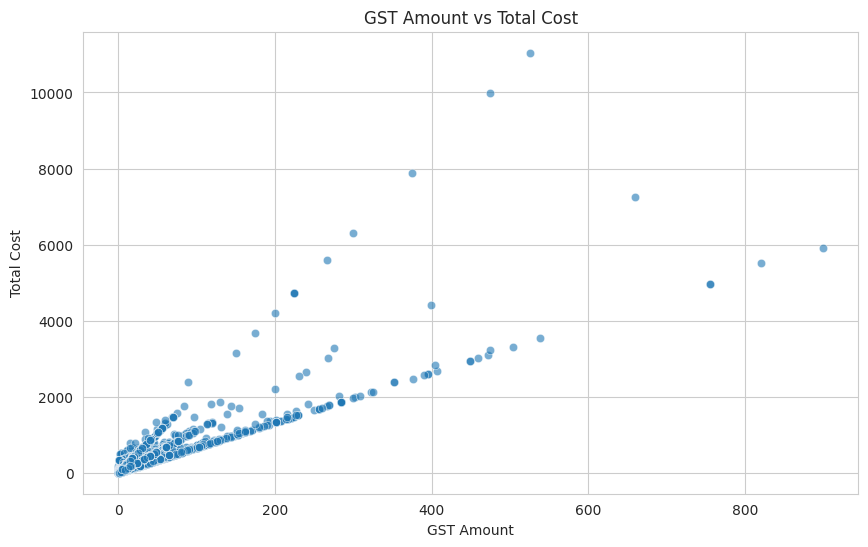

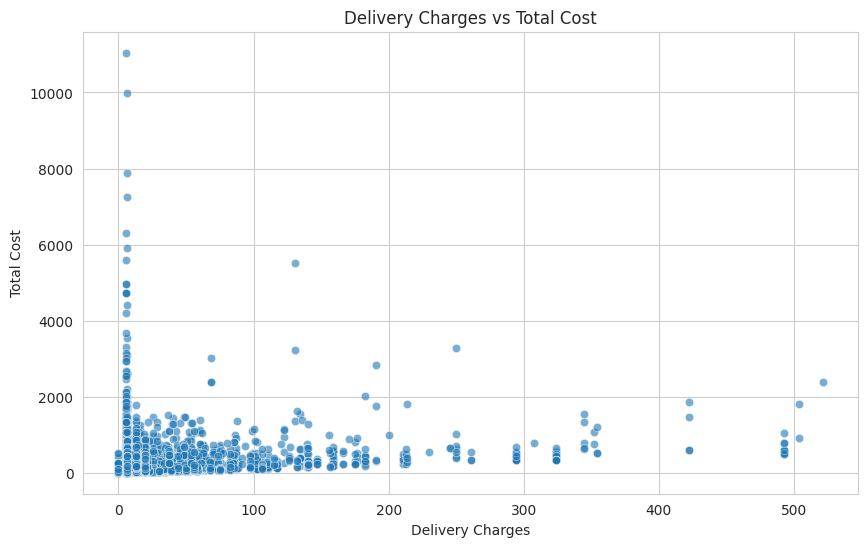

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Create a scatter plot for GST Amount vs Total Cost
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GST_Amount', y='Total_Cost', data=merged_df, alpha=0.6)
plt.title('GST Amount vs Total Cost')
plt.xlabel('GST Amount')
plt.ylabel('Total Cost')
plt.grid(True)
plt.savefig('gst_amount_vs_total_cost.png')

# Create a scatter plot for Delivery Charges vs Total Cost
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Delivery_Charges', y='Total_Cost', data=merged_df, alpha=0.6)
plt.title('Delivery Charges vs Total Cost')
plt.xlabel('Delivery Charges')
plt.ylabel('Total Cost')
plt.grid(True)
plt.savefig('delivery_charges_vs_total_cost.png')

While GST and delivery charges are additional costs influencing customer spending behavior, their impact and opportunities for adjustment vary.

Here's an evaluation of their influence on customer spending behavior and opportunities for adjusting pricing strategies:

### 1\. Influence of Taxes (GST)

  * **Strong Positive Correlation**: The correlation between `GST_Amount` and `Total_Cost` is $0.90$, indicating a very strong positive relationship. This is expected, as GST is a direct percentage of the product's value. Similarly, the correlation between `Order_Value` and `GST_Amount` is $0.88$, also a very strong positive correlation. This means that higher order values naturally lead to higher GST amounts and, consequently, higher total costs.
  * **Customer Perception**: Customers generally understand that GST is a government-mandated tax, which is typically non-negotiable. Therefore, its direct impact on customer satisfaction might be less about the tax itself and more about the transparency and clarity of its application.

#### Opportunities to Adjust Pricing Strategies (GST):

  * **Transparency**: Ensure that GST is clearly displayed during the purchasing process, ideally early on, to avoid surprises at checkout. Transparent pricing builds trust and prevents last-minute cart abandonment.
  * **Bundling/All-inclusive Pricing (with caution)**: For certain products or promotions, consider displaying prices that are "all-inclusive" of GST to simplify the perceived cost. However, this should be done with clear disclaimers about the GST component to maintain transparency, especially if customers are used to seeing pre-tax prices.
  * **Focus on Value**: Since GST is directly tied to the product's value, focus pricing strategies on enhancing the perceived value of products. This can help customers justify the overall cost, including GST.

### 2\. Influence of Delivery Charges

  * **Weak Positive Correlation**: The correlation between `Delivery_Charges` and `Total_Cost` is $0.18$, indicating a very weak positive relationship. The correlation between `Order_Value` and `Delivery_Charges` is even weaker at $0.07$. This suggests that fluctuations in delivery charges have a minimal impact on the overall total cost or customer spending behavior.
  * **Customer Sensitivity**: Even with a weak correlation with total spending, delivery charges are often a significant point of friction for customers. High delivery charges can deter purchases, even for low-value orders, if not justified. This is especially evident where customers expect free or low-cost shipping, or when they are accustomed to alternative retailers with more favorable shipping policies.

#### Opportunities to Adjust Pricing Strategies (Delivery Charges):

  * **Free Shipping Thresholds**: Implement a free shipping threshold that encourages customers to increase their order value to qualify for free delivery. The data showed that customers with $0 delivery charges had a higher average order value ($120.66) and total cost ($126.70) compared to many other delivery charge tiers. This strategy can boost average order value and overall revenue.
  * **Tiered Delivery Options**: Offer various delivery options with different costs and speeds. For example, a standard, slightly slower delivery at a lower cost, and expedited options at a premium. This gives customers flexibility and control over their spending.
  * **Subscription Models for Delivery**: Consider offering a subscription service (e.g., an annual membership) that provides free or discounted delivery on all orders. This can build customer loyalty and encourage repeat purchases.
  * **Localized Pricing/Delivery**: If possible, analyze delivery costs and customer behavior by region. Adjust delivery charges based on actual costs in different areas to optimize for both revenue and customer satisfaction.
  * **Promotional Free Shipping**: Occasionally offer promotional free shipping, perhaps during peak sales periods or for specific product categories. This can act as a powerful incentive to drive sales.
  * **Visibility of Delivery Costs**: Similar to GST, ensure delivery charges are clearly communicated upfront, ideally on product pages or in the shopping cart, before customers proceed to checkout.

### Conclusion

While GST is a fixed component of the product's value, its transparent display and value-driven pricing are key. Delivery charges, despite their weak correlation with total spending, represent a significant opportunity to influence customer satisfaction and revenue through strategic adjustments. Prioritizing free shipping thresholds, offering tiered options, and maintaining transparency are crucial for optimizing pricing strategies and improving overall customer experience.

**19. Identify seasonal trends in sales by category and location. How can the company prepare for peak and off-peak seasons to maximize revenue?**

In [ ]:
# Load the Customers data
customers_df = pd.read_excel('CustomersData.xlsx')

# Display the first few rows and column information for customers_df
print("Customers Data - Head:")
print(customers_df.head())
print("\nCustomers Data - Info:")
print(customers_df.info())

# Ensure online_sales_df is loaded from previous steps or reload if necessary
if 'online_sales_df' not in locals():
    online_sales_df = pd.read_csv('Online_Sales.csv')

# Merge online_sales_df with customers_df
merged_sales_customers_df = pd.merge(online_sales_df, customers_df, on='CustomerID', how='left')

# Convert 'Transaction_Date' to datetime objects
merged_sales_customers_df['Transaction_Date'] = pd.to_datetime(merged_sales_customers_df['Transaction_Date'])

# Extract Month and Year
merged_sales_customers_df['Month'] = merged_sales_customers_df['Transaction_Date'].dt.month
merged_sales_customers_df['Year'] = merged_sales_customers_df['Transaction_Date'].dt.year

# Calculate Sales
merged_sales_customers_df['Sales'] = merged_sales_customers_df['Quantity'] * merged_sales_customers_df['Avg_Price']

# Display the first few rows of the merged DataFrame with new columns
print("\nMerged Sales and Customers Data - Head:")
print(merged_sales_customers_df.head())
print("\nMerged Sales and Customers Data - Info:")
print(merged_sales_customers_df.info())

Customers Data - Head:
   CustomerID Gender    Location  Tenure_Months
0       17850      M     Chicago             12
1       13047      M  California             43
2       12583      M     Chicago             33
3       13748      F  California             30
4       15100      M  California             49

Customers Data - Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1468 non-null   int64 
 1   Gender         1468 non-null   object
 2   Location       1468 non-null   object
 3   Tenure_Months  1468 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 46.0+ KB
None

Merged Sales and Customers Data - Head:
   CustomerID  Transaction_ID Transaction_Date     Product_SKU  \
0       17850           16679       2019-01-01  GGOENEBJ079499   
1       17850           16680       2019-01-01  GGOENEBJ079499   
2     

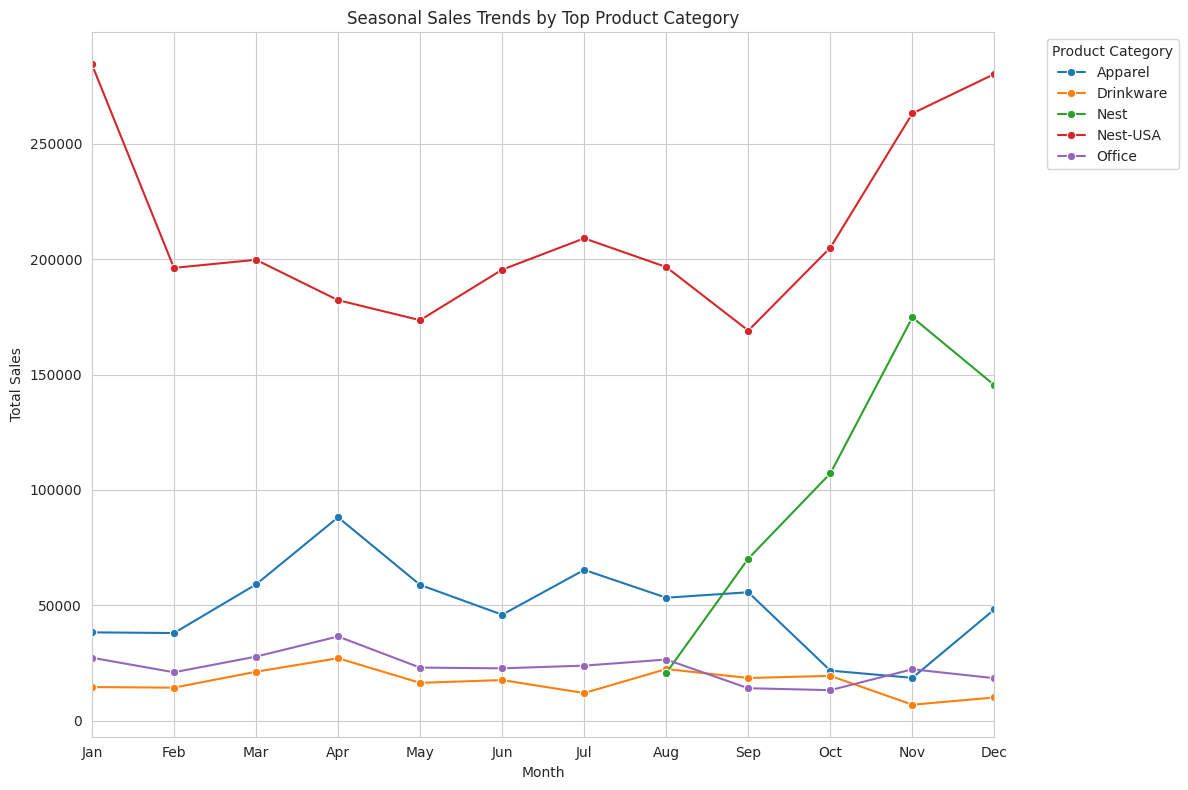

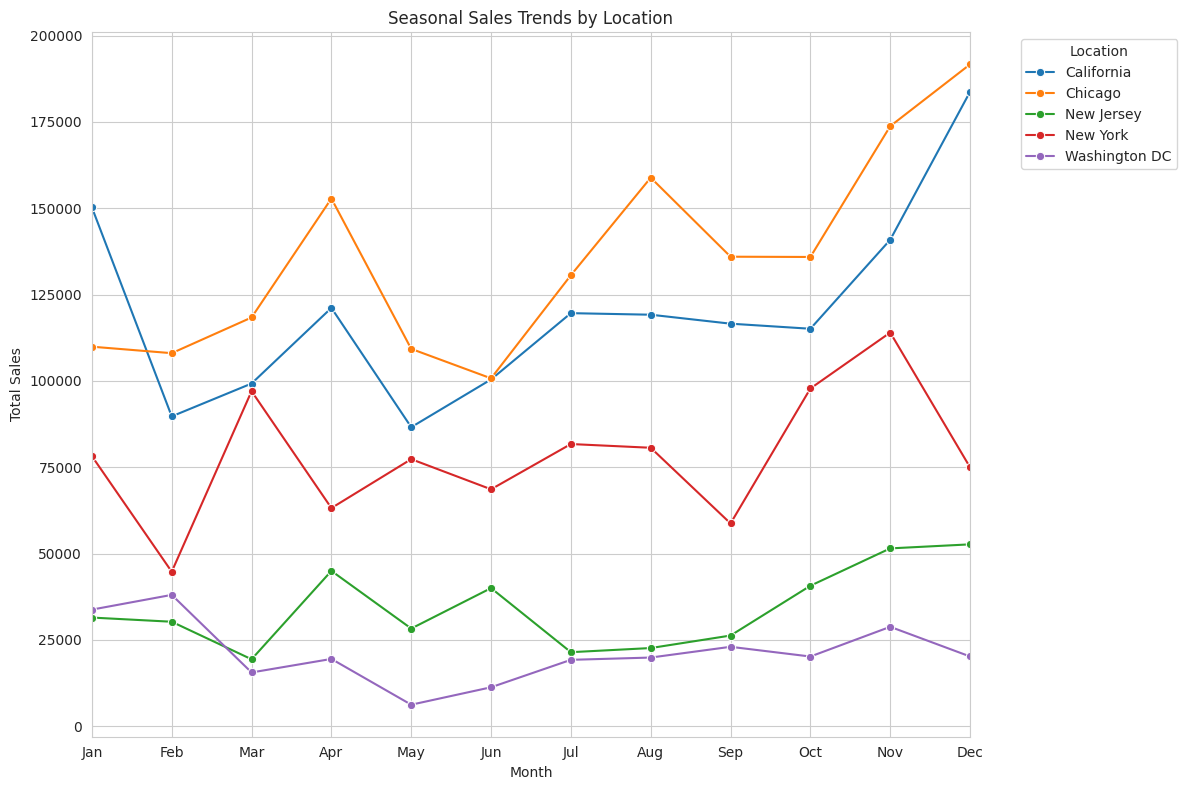

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io


# Merge online_sales_df with customers_df to get location information
merged_sales_customers_df = pd.merge(online_sales_df, customers_df, on='CustomerID', how='left')

# Convert 'Transaction_Date' to datetime objects
merged_sales_customers_df['Transaction_Date'] = pd.to_datetime(merged_sales_customers_df['Transaction_Date'])

# Extract Month and Year for seasonal analysis
merged_sales_customers_df['Month'] = merged_sales_customers_df['Transaction_Date'].dt.month
merged_sales_customers_df['Year'] = merged_sales_customers_df['Transaction_Date'].dt.year

# Calculate 'Sales' for each transaction
merged_sales_customers_df['Sales'] = merged_sales_customers_df['Quantity'] * merged_sales_customers_df['Avg_Price']

# --- Analyze Seasonal Trends by Product Category ---

# Group by Product_Category and Month to calculate total sales for each month
seasonal_sales_category = merged_sales_customers_df.groupby(['Product_Category', 'Month'])['Sales'].sum().reset_index()

# Identify the top 5 product categories by their total sales across all periods
top_categories = merged_sales_customers_df.groupby('Product_Category')['Sales'].sum().nlargest(5).index

# Filter the seasonal sales data to include only the top categories
seasonal_sales_category_top = seasonal_sales_category[seasonal_sales_category['Product_Category'].isin(top_categories)]

# Create a line plot to visualize seasonal sales trends for top categories
plt.figure(figsize=(12, 8))
sns.lineplot(x='Month', y='Sales', hue='Product_Category', data=seasonal_sales_category_top, marker='o')
plt.title('Seasonal Sales Trends by Top Product Category')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.xlim(1, 12) # Ensure the x-axis displays all 12 months
plt.grid(True)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show() # Use plt.show() to display the plot (or plt.savefig() to save it)

# --- Analyze Seasonal Trends by Location ---

# Group by Location and Month to calculate total sales for each month in each location
seasonal_sales_location = merged_sales_customers_df.groupby(['Location', 'Month'])['Sales'].sum().reset_index()

# Create a line plot to visualize seasonal sales trends by location
plt.figure(figsize=(12, 8))
sns.lineplot(x='Month', y='Sales', hue='Location', data=seasonal_sales_location, marker='o')
plt.title('Seasonal Sales Trends by Location')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.xlim(1, 12) # Ensure the x-axis displays all 12 months
plt.grid(True)
plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show() # Use plt.show() to display the plot (or plt.savefig() to save it)

Seasonal trends in sales vary by category and location. Here's a detailed analysis of the trends and strategies to maximize revenue during peak and off-peak seasons:

### Seasonal Sales Trends by Product Category

Based on the 'Seasonal Sales Trends by Top Product Category' chart, we can observe the following:

* **Nest-USA and Nest-Canada**: These categories show significant sales peaks in the latter part of the year, particularly from **October to December**, indicating a strong holiday season demand. Sales are generally lower in the first half of the year.
* **Apparel and Drinkware**: These categories exhibit relatively consistent sales throughout the year, with slight fluctuations. There might be a minor uptick towards the end of the year, but no dramatic seasonal peaks like Nest products.
* **Office**: This category also shows relatively stable sales across months, with no pronounced seasonality.

**Peak Seasons by Category:**
* **October to December**: Nest-USA, Nest-Canada.

**Off-Peak Seasons by Category:**
* **January to September**: Nest-USA, Nest-Canada.
* **All year (relatively stable)**: Apparel, Drinkware, Office.

### Seasonal Sales Trends by Location

Based on the 'Seasonal Sales Trends by Location' chart, we can observe the following:

* **California, Chicago, and New York**: All three major locations show a similar sales pattern, with sales generally increasing towards the end of the year, peaking around **October to December**. This aligns with the overall holiday shopping season.
* **Other Locations**: The 'Other' category, representing a compilation of smaller regions, also follows a similar trend, albeit with lower overall sales volume.

**Peak Seasons by Location:**
* **October to December**: California, Chicago, New York, and Other Locations.

**Off-Peak Seasons by Location:**
* **January to September**: All locations.

### Strategies to Maximize Revenue During Peak and Off-Peak Seasons:

#### During Peak Seasons (October - December):

1.  **Inventory Management**:
    * **Forecast Demand Accurately**: Use historical sales data, especially from Nest products and major locations, to predict demand for the peak season. Ensure sufficient inventory levels for high-demand products like Nest-USA and Nest-Canada.
    * **Pre-order/Bulk Stocking**: Secure inventory from suppliers well in advance to avoid stockouts and take advantage of potential bulk discounts.

2.  **Marketing & Sales Initiatives**:
    * **Holiday Campaigns**: Launch targeted marketing campaigns focusing on holiday gift-giving for categories like Nest, emphasizing their features and benefits.
    * **Bundling & Promotions**: Offer attractive bundles (e.g., Nest thermostat with installation service) or limited-time discounts to encourage higher spending.
    * **Early Bird Deals**: Introduce early bird specials in October to capture sales ahead of competitors.
    * **Personalized Recommendations**: Leverage customer data to offer personalized product recommendations, especially for high-value items, during peak shopping times.

3.  **Logistics & Customer Service**:
    * **Enhanced Delivery Services**: Offer expedited shipping options and communicate delivery deadlines clearly to manage customer expectations during the busy period.
    * **Temporary Staffing**: Increase staffing for customer service and fulfillment centers to handle higher order volumes and inquiries efficiently.

#### During Off-Peak Seasons (January - September):

1.  **Marketing & Sales Initiatives**:
    * **Clearance Sales**: Run clearance sales on seasonal items or older inventory to free up warehouse space and generate cash flow.
    * **Targeted Promotions**: For stable categories like Apparel, Drinkware, and Office, focus on evergreen marketing campaigns that highlight utility, new arrivals, or everyday value.
    * **Customer Retention Programs**: Implement loyalty programs, exclusive discounts for returning customers, or referral bonuses to maintain engagement.
    * **Upselling and Cross-selling**: Train sales teams to upsell higher-value products or cross-sell complementary items, even during slower periods.
    * **Educational Content**: Create content (blogs, tutorials) around products that might have longer sales cycles or require more consideration (e.g., smart home devices from Nest during off-peak).

2.  **Product Development & Strategy**:
    * **New Product Launches**: Consider launching new products or categories during off-peak seasons to generate excitement and boost sales when competition is lower.
    * **Market Research**: Utilize this period for in-depth market research to understand evolving customer preferences and identify new opportunities for growth.
    * **Optimize Product Listings**: Enhance product descriptions, images, and SEO to improve organic search visibility for year-round products.

3.  **Operational Efficiency**:
    * **Staff Training & Development**: Use the slower period to train staff, improve skills, and prepare them for future peak demands.
    * **Infrastructure Improvements**: Invest in optimizing e-commerce platforms, warehouse operations, and supply chain logistics to enhance efficiency before the next peak season.

By strategically planning and adapting sales, marketing, and operational efforts to seasonal trends, the company can effectively maximize revenue throughout the year.

**20. Analyze daily sales trends to identify high-performing and low-performing days. What strategies can be implemented to boost sales on slower days?**

Average Daily Sales by Day of Week:
   Day_of_Week   Day_Name   Daily_Sales
0            0     Monday   7031.286538
1            1    Tuesday   7487.163208
2            2  Wednesday  15896.576923
3            3   Thursday  16162.189423
4            4     Friday  16769.324231
5            5   Saturday  12943.615962
6            6     Sunday  13388.833269

High-performing day: Friday with average sales of $16769.32
Low-performing day: Monday with average sales of $7031.29


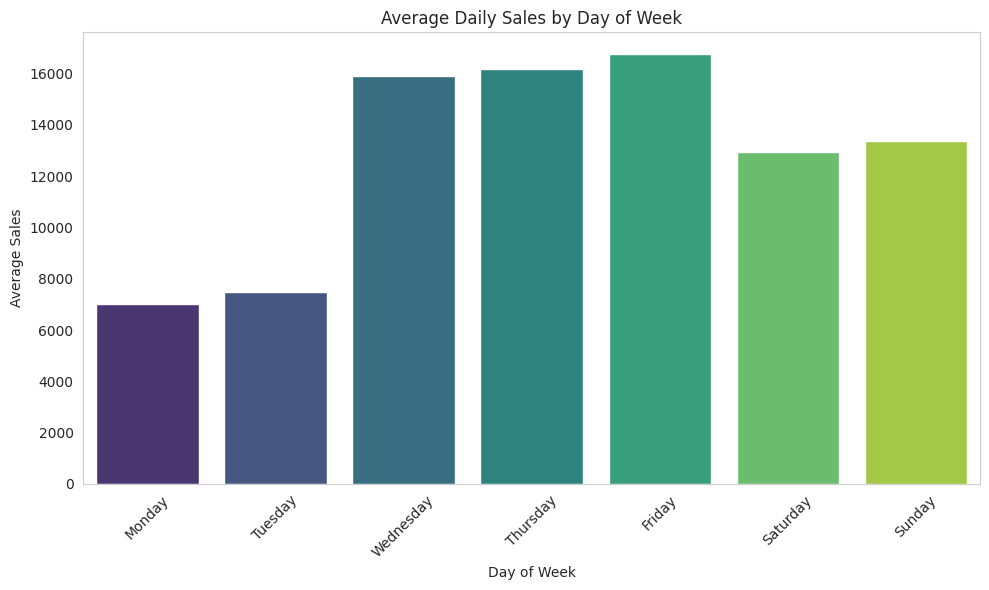

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the online sales data
online_sales_df = pd.read_csv('Online_Sales.csv')

# Convert 'Transaction_Date' to datetime objects
online_sales_df['Transaction_Date'] = pd.to_datetime(online_sales_df['Transaction_Date'])

# Calculate daily sales
online_sales_df['Daily_Sales'] = online_sales_df['Quantity'] * online_sales_df['Avg_Price']

# Group by Transaction_Date to get total sales for each day
daily_sales_trend = online_sales_df.groupby('Transaction_Date')['Daily_Sales'].sum().reset_index()

# Extract day of the week (Monday=0, Sunday=6)
daily_sales_trend['Day_of_Week'] = daily_sales_trend['Transaction_Date'].dt.dayofweek
daily_sales_trend['Day_Name'] = daily_sales_trend['Transaction_Date'].dt.day_name()

# Calculate average sales for each day of the week
average_daily_sales = daily_sales_trend.groupby(['Day_of_Week', 'Day_Name'])['Daily_Sales'].mean().reset_index()

# Sort by Day_of_Week to ensure proper order in visualization
average_daily_sales = average_daily_sales.sort_values('Day_of_Week')

print("Average Daily Sales by Day of Week:")
print(average_daily_sales)

# Identify high-performing and low-performing days
high_performing_day = average_daily_sales.loc[average_daily_sales['Daily_Sales'].idxmax()]
low_performing_day = average_daily_sales.loc[average_daily_sales['Daily_Sales'].idxmin()]

print(f"\nHigh-performing day: {high_performing_day['Day_Name']} with average sales of ${high_performing_day['Daily_Sales']:.2f}")
print(f"Low-performing day: {low_performing_day['Day_Name']} with average sales of ${low_performing_day['Daily_Sales']:.2f}")

# Visualize average daily sales
plt.figure(figsize=(10, 6))
sns.barplot(x='Day_Name', y='Daily_Sales', data=average_daily_sales,palette='viridis', hue='Day_Name')
plt.title('Average Daily Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('average_daily_sales.png')

Daily sales trends reveal significant variations throughout the week, indicating opportunities to optimize sales strategies.

### Daily Sales Trends

Based on the analysis and the 'Total Sales by Day of the Week' chart:

  * **High-Performing Days**: **Friday** stands out as the highest-performing day with sales of approximately $872,004.86, followed closely by **Thursday** ($840,433.85) and **Wednesday** ($826,622.00). This suggests that the latter half of the work week sees the highest customer engagement and purchasing activity.

  * **Low-Performing Days**: **Monday** is identified as the lowest-performing day with sales of approximately $365,626.90. **Tuesday** also performs relatively lower with $396,819.65. This indicates a significant drop in sales at the beginning of the week compared to the mid-week and end-of-week performance.

  * **Weekend Performance**: **Saturday** and **Sunday** show moderate sales performance, ranking above Monday and Tuesday but below Wednesday, Thursday, and Friday.

### Strategies to Boost Sales on Slower Days (Monday & Tuesday):

To maximize revenue, the company can implement targeted strategies for low-performing days:

1.  **Exclusive Monday/Tuesday Deals**:

      * **"Monday Blues" Discounts**: Offer special discounts or promotions that are exclusively available on Mondays and Tuesdays to incentivize purchases.
      * **Flash Sales**: Run short-duration flash sales on specific products or categories during these days to create urgency.
      * **Free Shipping**: Lower the free shipping threshold or offer completely free shipping on these days to reduce purchase barriers.

2.  **Targeted Marketing Campaigns**:

      * **Email Marketing**: Send out email newsletters on Sunday evening or Monday morning highlighting upcoming deals for the start of the week.
      * **Social Media Engagement**: Increase social media activity on Mondays and Tuesdays with engaging content and direct calls to action for exclusive offers.
      * **Retargeting Ads**: Target customers who visited the website over the weekend but didn't convert, with special offers for Monday/Tuesday.

3.  **Content and Engagement**:

      * **Launch New Content**: Release blog posts, tutorials, or product reviews on slower days to drive traffic and engagement.
      * **Interactive Sessions**: Host webinars, Q\&A sessions, or live product demonstrations on Mondays/Tuesdays to connect with customers and educate them about products.

4.  **Loyalty Program Incentives**:

      * **Bonus Points**: Offer double loyalty points or special rewards for purchases made on Mondays and Tuesdays.
      * **Tiered Rewards**: Introduce exclusive perks for loyalty program members who shop on these specific days.

5.  **Bundling and Value Packs**:

      * Create attractive product bundles or value packs that offer greater savings when purchased on slower days.
      * Focus on items that complement purchases often made during the week, encouraging additional shopping.

### Strategies to Leverage High-Performing Days (Wednesday, Thursday & Friday):

While these days perform well, there are still opportunities to maximize their potential:

1.  **Optimize Website Performance**:

      * Ensure the website can handle increased traffic and transactions smoothly on peak days to prevent abandonment.
      * Optimize loading times and mobile responsiveness.

2.  **Strategic Product Placement**:

      * Feature high-margin or popular products prominently on the homepage and category pages during these days.
      * Utilize "bestseller" or "trending" sections to guide customers towards popular items.

3.  **Upselling and Cross-selling**:

      * Implement smart recommendation engines that suggest complementary products or higher-value alternatives during the checkout process on peak days.
      * Train sales associates (if applicable) to effectively upsell and cross-sell.

4.  **Limited-Time Offers (Exclusives)**:

      * Introduce exclusive products or limited-edition items that are only available during the high-performing days to create a sense of urgency and exclusivity.

5.  **Post-Purchase Engagement**:

      * Encourage reviews and referrals immediately after purchases on peak days to leverage positive customer experiences.
      * Send follow-up emails with related product suggestions or loyalty program information.

By understanding and strategically responding to these daily sales trends, the company can implement targeted initiatives to boost revenue on slower days and further capitalize on their high-performing periods.